In [ ]:
import os 
import numpy as np
import pandas as pd

import seaborn as sns 
import scipy.stats as stats
import matplotlib.pyplot as plt

from tqdm import tqdm
from assocplots.manhattan import *
from matplotlib.lines import Line2D


### Raw tables (need to add snps annotations)

In [2]:
snps_annotations = pd.read_csv('../../data/genotype_information/snps_annotations_genome-version-3-64-1_with_gene_annotations_plus_LD_block_definition.txt')
snps_annotations['CHR'] = [int(snps_annotations['chrom'][idx].replace('MT','17').replace('CHR_', '')) for idx in snps_annotations.index ]

In [3]:
piQTL_raw_results_dec_2022 = pd.read_csv('../../results/04_eQTL_matrix/piQTL_dec2022_pval_results.txt', sep='\t')
piQTL_raw_results_june_2024 = pd.read_csv('../../results/04_eQTL_matrix/piQTL_june2024_pval_results.txt', sep='\t')
piQTL_raw_results_august_2024 = pd.read_csv('../../results/04_eQTL_matrix/piQTL_august2024_pval_results.txt', sep='\t')

In [4]:
snps_strict_info = snps_annotations[['SNP', 'CHR','position','chrom', 'locus_id', 'name', 'snps_class_up', 'snps_class_down', 'is_in_gene', 'gene_locus', 'gene_name', 'LD_b075', 'LD_b050']]

In [5]:
piQTL_raw_results_dec_2022_with_annotations = piQTL_raw_results_dec_2022.merge(snps_strict_info, on='SNP')
piQTL_raw_results_june_2024_with_annotations = piQTL_raw_results_june_2024.merge(snps_strict_info, on='SNP')
piQTL_raw_results_august_2024_with_annotations = piQTL_raw_results_august_2024.merge(snps_strict_info, on='SNP')

In [6]:
print(12054 * 62 * 5 *2)

7473480


In [7]:
piQTL_raw_results_dec_2022_with_annotations.sort_values(['gene', 'SNP']).reset_index(drop=True).to_csv('../../results/04_eQTL_matrix/piQTL_dec2022_pval_results_annotated_order_by_condition_and_SNPs.txt', sep='\t')

piQTL_raw_results_june_2024_with_annotations.sort_values(['gene', 'SNP']).reset_index(drop=True).to_csv('../../results/04_eQTL_matrix/piQTL_june2024_pval_results_annotated_order_by_condition_and_SNPs.txt', sep='\t')

piQTL_raw_results_august_2024_with_annotations.sort_values(['gene', 'SNP']).reset_index(drop=True).to_csv('../../results/04_eQTL_matrix/piQTL_august2024_pval_results_annotated_order_by_condition_and_SNPs.txt', sep='\t')

### Functions for LD block processing

In [7]:
LD_table = pd.read_csv('../01_experimental_checks/LD_table.csv')
LD_table = LD_table.set_index('SNP')

In [9]:
def inblock(x, LD_block_list):
    for block in LD_block_list :
        if x in block:
            try:
                return '_'.join([ str(snp) for snp in block ])
            except:
                return block[0]

def identify_ld_blocks(ld_table, ld_threshold):
    ld_blocks = []
    current_block = []

    for idx, snp in tqdm(enumerate(ld_table.index), total=len(ld_table)):
        if not current_block:
            # First SNP in a block
            current_block.append(snp)
        else:
            # Check if the current SNP is in LD with the last SNP in the block
            if ld_table.loc[current_block[-1], str(snp)] >= ld_threshold:
                current_block.append(snp)
            else:
                # Start a new block
                ld_blocks.append(current_block)
                current_block = [snp]

    # Add the last block if it exists
    if current_block:
        ld_blocks.append(current_block)

    return ld_blocks

## PPI quantification (new equation)
- MTX+ + Condition X --> PPI-specific (+ untagged reference) Fitness influencued by the X condition
- MTX+ + no Drug --> PPI-specific (+ untagged reference) Fitness on the media 
- MTX- + Condition X --> Fitness influenced by the X condition only

#### All PPIs (MTX+) vs. All PPIs (MTX-) - Relative Fitness

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy import stats

### Relative fitness of the 61 PPIs in MTX+ vs MTX- conditions (average across the 5 drugs)

Pearson's r correlation score:0.58 - pvalue:1.04e-06 (noDrug)
Pearson's r correlation score:0.40 - pvalue:1.33e-03 (Fluconazole)
Pearson's r correlation score:0.60 - pvalue:2.90e-07 (Metformin)
Pearson's r correlation score:0.61 - pvalue:2.16e-07 (5-FC)
Pearson's r correlation score:0.52 - pvalue:1.47e-05 (Trifluoperazine)


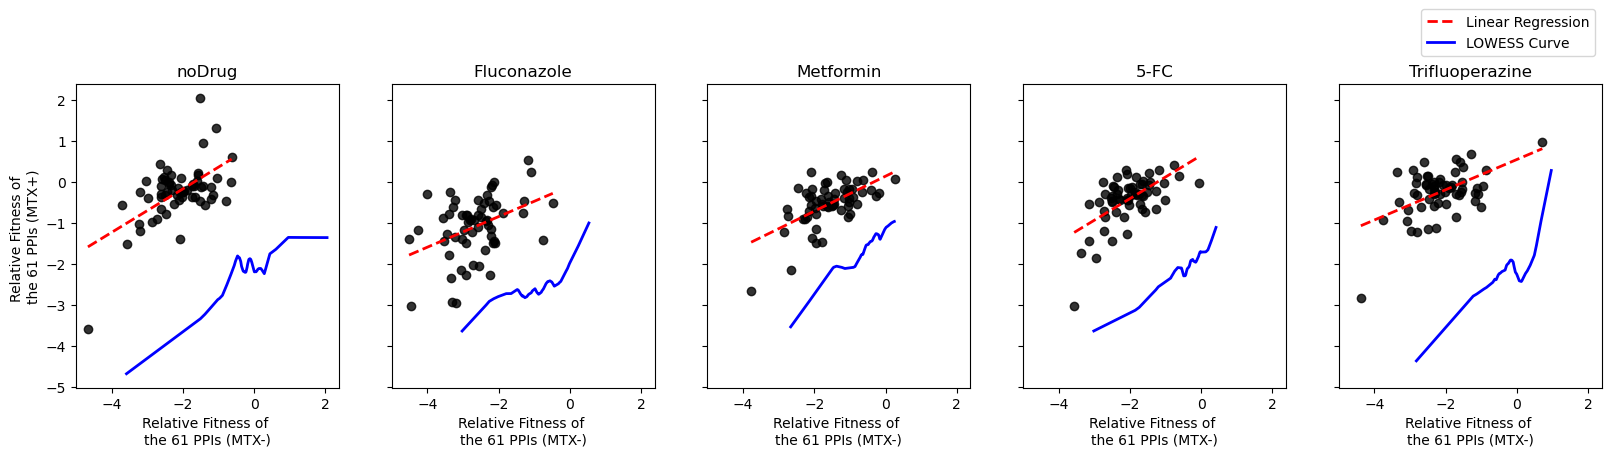

In [ ]:
CM = 1/2.54 # centimeters in inches   
DRUGS = ['noDrug', 'Fluconazole', 'Metformin', '5-FC', 'Trifluoperazine']

raw_relative_fitness = pd.read_csv('../../results/03_ppi_estimation/logratio/all_PPI_logratio_fitness.csv').rename(columns={'TAXA':'Condition'})
ppi_quantification = raw_relative_fitness.set_index('Condition').T.reset_index().rename(columns={'index':'Condition'})
avg_data = []
PPI_list = list(set([ f"{col.split('_')[0]}_{col.split('_')[1]}" for col in ppi_quantification['Condition'] ]))
for i in range(len(DRUGS)) : 
    DRUG = DRUGS[i]
    for PPI in PPI_list : 
        if 'noPPI' not in PPI : 
            PPI_Qs = ppi_quantification[(ppi_quantification['Condition'].str.contains(PPI)) & (ppi_quantification['Condition'].str.contains(DRUG))].set_index('Condition').T
            X = f'{PPI}_noMTX_{DRUG}_avg_logratio_Fitness'
            Y = f'{PPI}_MTX_{DRUG}_avg_logratio_Fitness'

            PPI_Qs = PPI_Qs.rename(columns={X:'noMTX', Y:'MTX'})
            avg_data.append([f'{PPI}_{DRUG}', PPI_Qs['MTX'].mean(), PPI_Qs['noMTX'].mean()])
    

AVG_FITNESS_ALL = pd.DataFrame(avg_data, columns=['Condition', 'noMTX', 'MTX'])

f, axes = plt.subplots(figsize=(50*CM, 10*CM), ncols=len(DRUGS), sharex=True, sharey=True)    
for i in range(len(DRUGS)) : 
    DRUG = DRUGS[i]
    AVG_FITNESS_PER_DRUG = AVG_FITNESS_ALL[AVG_FITNESS_ALL['Condition'].str.contains(DRUG)]
    
    sns.regplot(x=AVG_FITNESS_PER_DRUG['noMTX'], y=AVG_FITNESS_PER_DRUG['MTX'], color='black', ax=axes[i], marker='o', fit_reg=True, ci=None, line_kws={"linewidth": 2, 'color': 'red', 'linestyle': '--', 'label':'Linear Regression'})
    if i == 0:
        axes[0].set_ylabel(f'Relative Fitness of \nthe 61 PPIs (MTX+)')
    else:
        axes[i].set_ylabel('')
    axes[i].set_xlabel(f'Relative Fitness of \nthe 61 PPIs (MTX-)')
    # LOWESS curve
    lowess = sm.nonparametric.lowess(AVG_FITNESS_PER_DRUG['noMTX'], AVG_FITNESS_PER_DRUG['MTX'], frac=0.3)
    axes[i].plot(lowess[:, 0], lowess[:, 1], color='blue', linewidth=2, label='LOWESS Curve')
    axes[i].set_title(DRUG)
    pearson_corr, pvalue = stats.pearsonr(AVG_FITNESS_PER_DRUG['noMTX'], AVG_FITNESS_PER_DRUG['MTX'])
    print(f'Pearson\'s r correlation score:{pearson_corr:.2f} - pvalue:{pvalue:.2e} ({DRUG})')

plt.legend(loc='upper right', bbox_to_anchor=(1, 1.27))
plt.show()

# f.savefig('./all_PPI_relative_fitness_mean.eps', dpi=300)
# f.savefig('./all_PPI_relative_fitness_mean.pdf', dpi=300)
            

### Density plot with regression and LOWESS curve

/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


-2.020760059740567 0.4901054117142502


/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


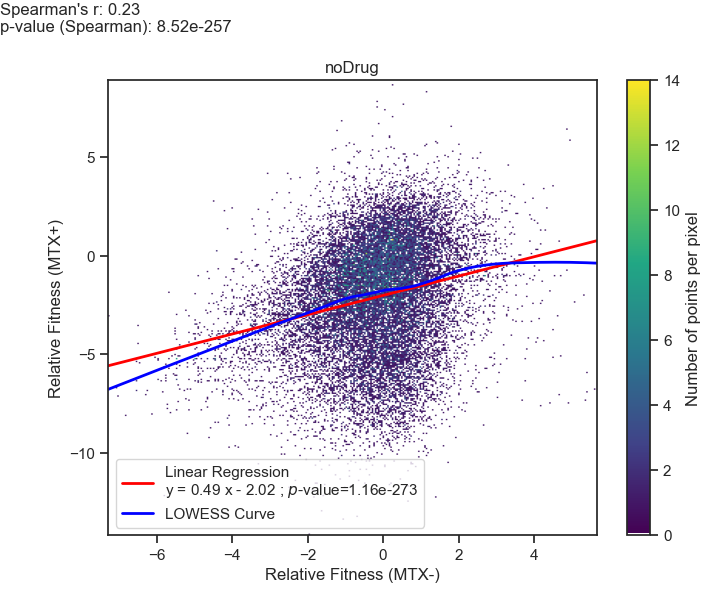

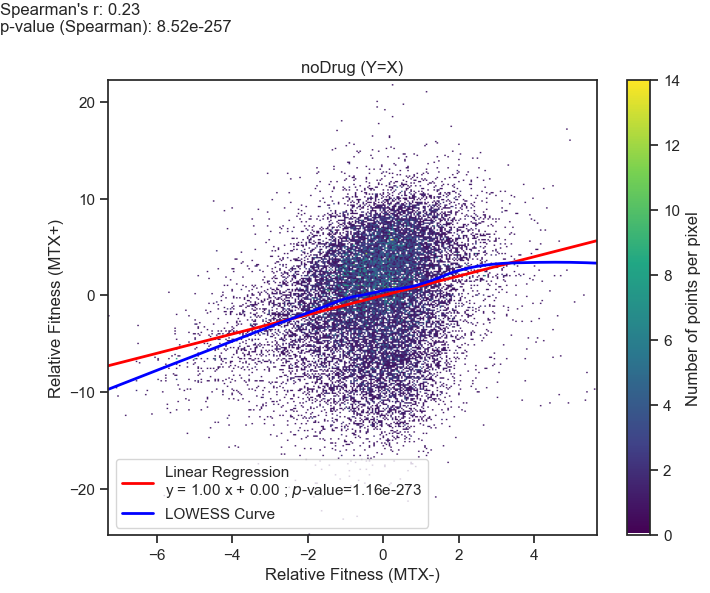

Residuals for noDrug:
[-0.66155545 -3.70909558  4.63512509 ... -0.84550046 -1.88491241
  1.7019201 ]
-2.112624076070231 0.49079433391970145


/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


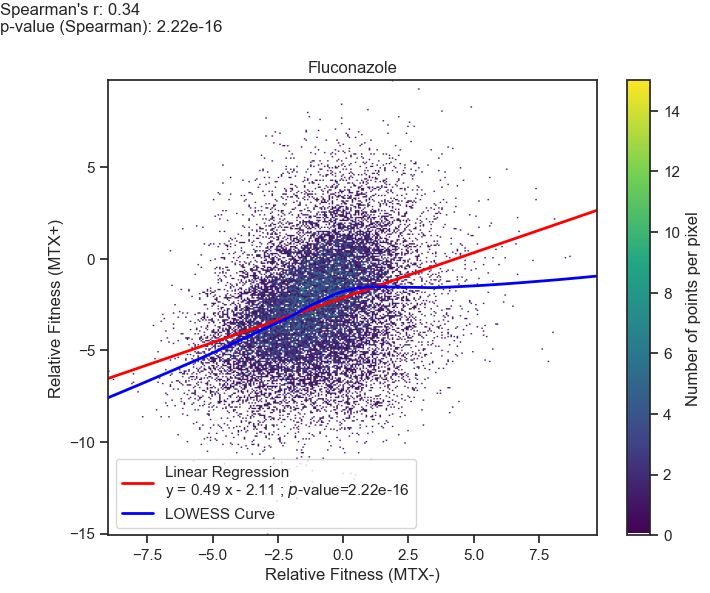

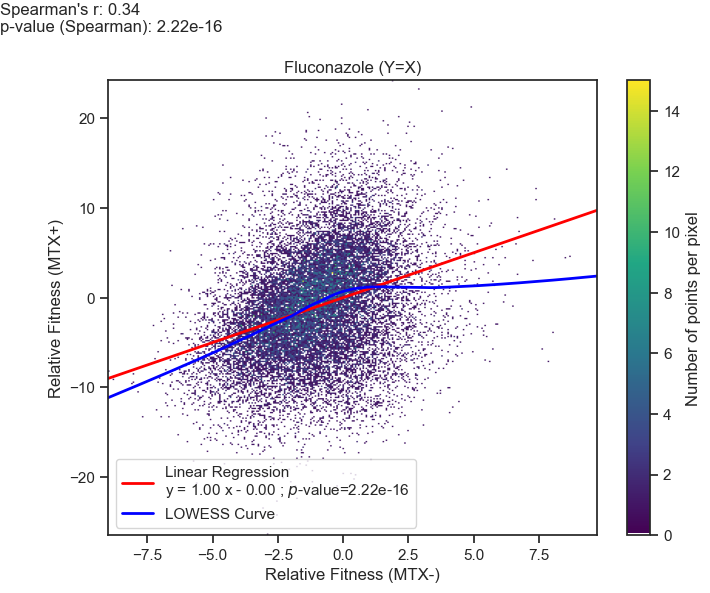

Residuals for Fluconazole:
[-0.4899014  -3.04064722  2.89070167 ...  0.43247677  1.90017519
  1.4447912 ]
-1.2199444033078428 0.6606239584434972


/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


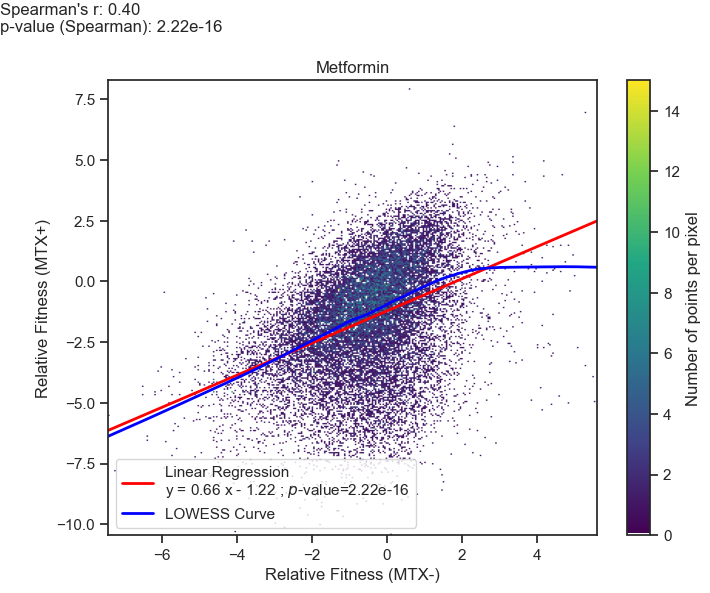

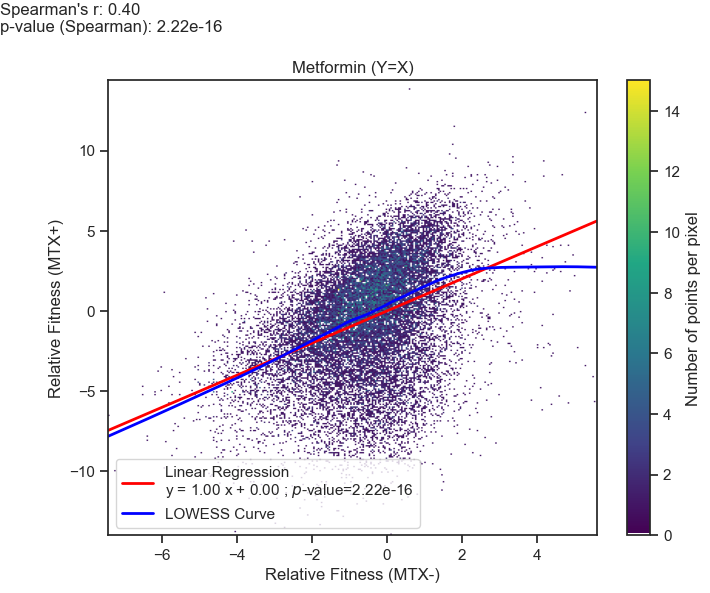

Residuals for Metformin:
[-0.99582268 -2.02619379  1.56726613 ...  2.8079152  -1.38995688
 -0.32476456]
-1.8252317965003697 0.5023202753986281


/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


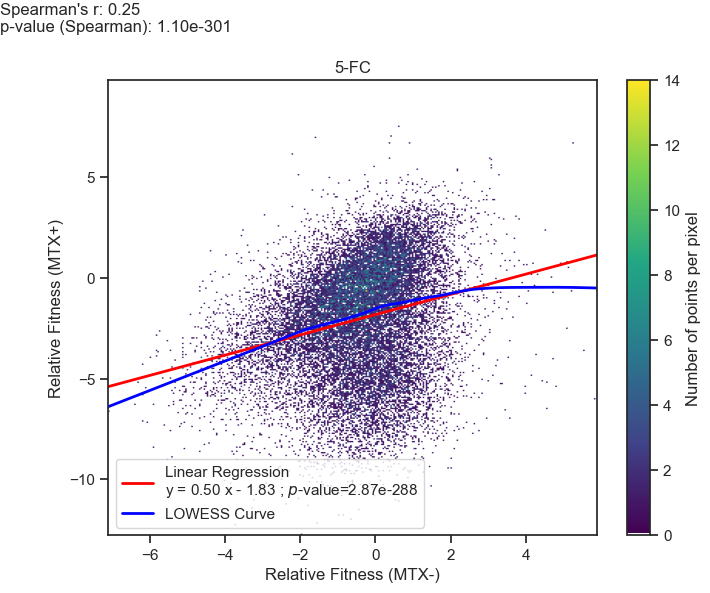

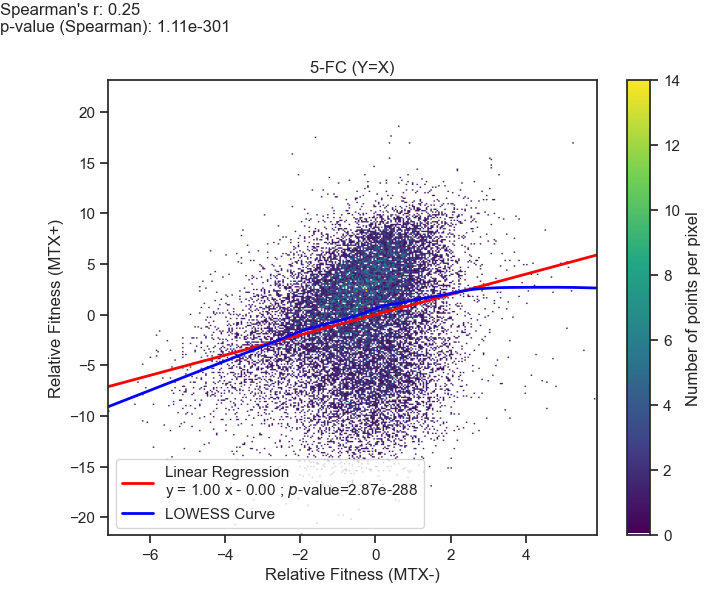

Residuals for 5-FC:
[-2.61014079 -3.63160671  2.07026712 ...  0.21566512 -1.44332154
  0.09935684]
-2.001453721649879 0.6038740285705052


/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


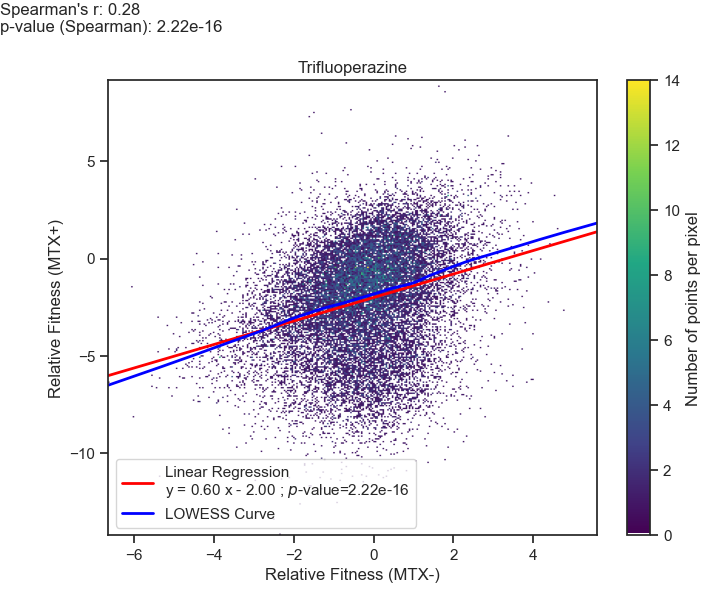

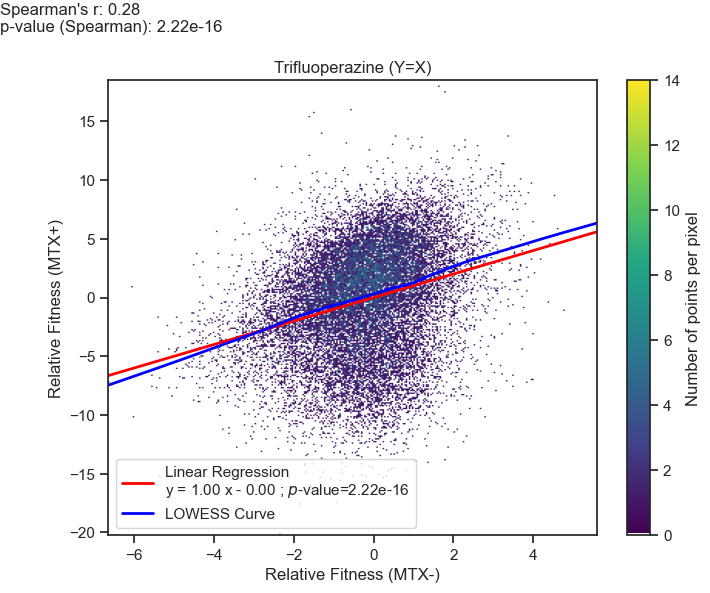

Residuals for Trifluoperazine:
[-1.5023995  -3.24059037  1.14603095 ...  2.06133546 -1.43589254
  1.02285242]


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import mpl_scatter_density  # adds projection='scatter_density'
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from scipy import stats


linear_model_params = {}
# Define the custom white_viridis colormap
white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

# Function to create density plot, linear regression, and LOWESS curve
def using_mpl_scatter_density_with_lines(ax, x, y, title):
    # Create density plot
    density = ax.scatter_density(x, y, cmap=white_viridis)

    # Perform linear regression using statsmodels
    X = sm.add_constant(x)  # Add a constant term (intercept) to the model
    model = sm.OLS(y, X).fit()
    intercept, slope = model.params
    if '(Y=X)' not in title:
        linear_model_params[title] = []
        linear_model_params[title].append(intercept)
        linear_model_params[title].append(slope)
        print(intercept, slope)
    p_value = model.pvalues[1]  # p-value for the slope
    residuals = model.resid

    # print(intercept, slope)
    if p_value == 0 :
        p_value = 2.22e-16
    if intercept > 0: 
        label_text = f'Linear Regression\ny = {slope:.2f} x + {np.abs(intercept):.2f} ; $p$-value={p_value:.2e}'
    elif intercept < 0:
        label_text = f'Linear Regression\ny = {slope:.2f} x - {np.abs(intercept):.2f} ; $p$-value={p_value:.2e}'
                 
    # Plot the linear regression line
    sns.regplot(x=x, y=y, ax=ax, scatter=False, color='red', ci=None, 
                label=label_text,
                line_kws={"linewidth": 2})

    # Plot the LOWESS curve
    lowess = sm.nonparametric.lowess(y, x, frac=0.3)
    ax.plot(lowess[:, 0], lowess[:, 1], color='blue', linewidth=2, label='LOWESS Curve')


    # Set title
    ax.set_xlabel('Relative Fitness (MTX-)')
    ax.set_ylabel('Relative Fitness (MTX+)')

    ## Pearson correlation
    spearman_corr, spearman_pvalue = stats.spearmanr(y, x)
    if spearman_pvalue == 0 :
        spearman_pvalue = 2.22e-16
    annotation_text  = (f'Spearman\'s r: {spearman_corr:.2f}\n'
                        f'p-value (Spearman): {spearman_pvalue:.2e}')
    
    ax.annotate(annotation_text, xy=(0, 1), xycoords='figure fraction', fontsize=12,
                horizontalalignment='left', verticalalignment='top')


    ax.set_title(title)
    # Show the legend for the lines, placed outside the panel
    ax.legend(loc='lower left', bbox_to_anchor=(0, 0))
    
    return density, residuals, p_value, slope, intercept

# Load your data
raw_relative_fitness = pd.read_csv('../../results/03_ppi_estimation/logratio/all_PPI_logratio_fitness.csv').rename(columns={'TAXA':'Condition'})
ppi_quantification = raw_relative_fitness.set_index('Condition').T.reset_index().rename(columns={'index':'Condition'})
PPI_list = list(set([f"{col.split('_')[0]}_{col.split('_')[1]}" for col in ppi_quantification['Condition']]))

sns.set_theme(style="ticks")
CM = 1/2.54  # centimeters in inches
DRUGS = ['noDrug', 'Fluconazole', 'Metformin', '5-FC', 'Trifluoperazine']

# Loop through each drug and generate the density plots with regression and LOWESS
for i in range(len(DRUGS)):
    DRUG = DRUGS[i]
    all_MTX = []
    all_noMTX = []
    
    for PPI in PPI_list:
        if 'noPPI' not in PPI:
            PPI_Qs = ppi_quantification[(ppi_quantification['Condition'].str.contains(PPI)) & (ppi_quantification['Condition'].str.contains(DRUG))].set_index('Condition').T
            X = f'{PPI}_noMTX_{DRUG}_avg_logratio_Fitness'
            Y = f'{PPI}_MTX_{DRUG}_avg_logratio_Fitness'

            for PPI_Q in PPI_Qs[X]:
                all_noMTX.append(PPI_Q)
            for PPI_Q in PPI_Qs[Y]:
                all_MTX.append(PPI_Q)

    # Create a density plot with regression and LOWESS for each drug
    fig = plt.figure(figsize=(20*CM, 15*CM))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    density, residuals, p_value, slope, intercept = using_mpl_scatter_density_with_lines(ax, all_noMTX, all_MTX, DRUG)
    # Add a colorbar for the density
    fig.colorbar(density, label='Number of points per pixel')


    fig2 = plt.figure(figsize=(20*CM, 15*CM))
    ax2 = fig2.add_subplot(1, 1, 1, projection='scatter_density')
    corrected_all_MTX = (np.array(all_MTX) - intercept) / slope
    corrected_density, corrected_residuals, corrected_p_value, corrected_slope, corrected_intercept = using_mpl_scatter_density_with_lines(ax2, all_noMTX, corrected_all_MTX, f'{DRUG} (Y=X)')
    # Add a colorbar for the density
    fig2.colorbar(corrected_density, label='Number of points per pixel')

    fig.canvas.draw()
    fig2.canvas.draw()
    plt.show()

    # fig.savefig(f'./density_plot_with_lines_all_PPI_relative_fitness_{DRUG}_V2.pdf', dpi=300)
    # fig.savefig(f'./density_plot_with_lines_all_PPI_relative_fitness_{DRUG}_V2.eps', dpi=300)
    # fig2.savefig(f'./density_plot_with_lines_all_PPI_relative_fitness_{DRUG}_YequalX_V2.pdf', dpi=300)
    # fig2.savefig(f'./density_plot_with_lines_all_PPI_relative_fitness_{DRUG}_YequalX_V2.eps', dpi=300)
    # Print the residuals and the p-value
    print(f'Residuals for {DRUG}:')
    print(residuals)

____

## PPI quantification (MTX - noMTX)

In [13]:
ppi_quantification = pd.read_csv('../../results/03_ppi_estimation/logratio/all_PPI_logratio_fitness_before_downsampling_minus_ref_for_eQTL_matrix.csv').rename(columns={'Unnamed: 0':'Condition'}) 

In [14]:
def label_new_metric(x):
    PPI = f"{x.split('_')[0]}_{x.split('_')[1]}"
    DRUG = x.split('_')[3] 
    MTX = x.split('_')[2] 
    if MTX == 'MTX':
        new_MTX = 'noMTX'
        x += f'_delta_{new_MTX}_{DRUG}_avg_logratio_Fitness_minus_ref'
        return x


In [15]:
## For DataFrame substraction, make sure to have the same column names and rows names
Fitness_MTX_ConditionX = ppi_quantification[ppi_quantification['Condition'].str.contains('_MTX_')].reset_index(drop=True)
Fitness_noMTX_ConditionX = ppi_quantification[ppi_quantification['Condition'].str.contains('_noMTX_')].reset_index(drop=True)

## Index for final table
deltaCondition_MTX_noMTX = Fitness_MTX_ConditionX['Condition'].apply(label_new_metric)


In [16]:
linear_model_params

{'noDrug': [np.float64(-2.020760059740567), np.float64(0.4901054117142502)],
 'Fluconazole': [np.float64(-2.112624076070231),
  np.float64(0.49079433391970145)],
 'Metformin': [np.float64(-1.2199444033078428),
  np.float64(0.6606239584434972)],
 '5-FC': [np.float64(-1.8252317965003697), np.float64(0.5023202753986281)],
 'Trifluoperazine': [np.float64(-2.001453721649879),
  np.float64(0.6038740285705052)]}

In [17]:
from tqdm import tqdm 

# Iterate over the rows in Fitness_MTX_ConditionX DataFrame
for idx in tqdm(Fitness_MTX_ConditionX.index):
    # Extract the drug name from the 'Condition' column
    DRUG = Fitness_MTX_ConditionX['Condition'][idx].split('_')[3]

    # Get the intercept and slope from the linear_model_params dictionary
    intercept = linear_model_params[DRUG][0]
    slope = linear_model_params[DRUG][1]

    # Perform the (values - intercept) / slope calculation for all values in the row
    normalized_values = (Fitness_MTX_ConditionX.iloc[idx, 1:].values - intercept) / slope
    
    # Replace the original values in the DataFrame with the normalized values
    Fitness_MTX_ConditionX.iloc[idx, 1:] = normalized_values

100%|██████████| 310/310 [00:11<00:00, 26.90it/s]


In [18]:
Fitness_MTX_ConditionX

,Condition,6,7,14,15,17,20,22,27,29,...,1038,1040,1046,1050,1052,1065,1069,17_2,40_2,180_2
0,GTR1_SLM4_MTX_noDrug_avg_logratio_Fitness_minu...,20.508511,20.430145,26.106967,20.362163,18.891551,20.758572,18.873267,22.375533,17.274590,...,25.061912,21.748413,16.020963,27.565705,18.718195,26.629644,28.554397,17.698006,23.622604,18.482578
1,GTR1_SLM4_MTX_5-FC_avg_logratio_Fitness_minus_ref,18.714996,20.234016,22.353905,18.354101,18.040056,21.288018,15.972834,20.030818,18.773618,...,24.524538,19.430865,18.074114,25.811348,17.137355,21.118878,25.411783,18.132735,21.439319,16.354816
2,GTR1_SLM4_MTX_Fluconazole_avg_logratio_Fitness...,20.529488,17.836041,17.891963,17.300105,25.329822,21.971066,17.722928,25.072563,20.702600,...,18.616523,18.420265,21.714810,21.971066,27.112858,29.228812,27.223040,17.896040,19.933553,21.527810
3,GTR1_SLM4_MTX_Metformin_avg_logratio_Fitness_m...,12.056746,11.353427,13.166810,11.566321,9.813810,14.554052,10.641141,13.283986,10.938071,...,13.575597,12.835666,10.083361,17.172358,11.083876,14.797706,13.881115,11.083876,11.840736,10.488855
4,GTR1_SLM4_MTX_Trifluoperazine_avg_logratio_Fit...,15.477833,14.319691,19.549686,13.322677,15.886063,15.680783,12.228138,19.464565,13.681162,...,18.376423,16.455809,12.320070,20.980629,13.196821,15.680783,20.741831,14.509150,19.133427,13.245301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,noPPI_reference_MTX_noDrug_avg_logratio_Fitnes...,11.232994,16.635287,19.075063,16.224863,12.967763,11.052110,28.614154,20.705856,7.096692,...,16.725655,10.962629,5.956338,12.669070,14.411368,15.332389,20.581225,11.177447,31.706709,6.756050
306,noPPI_reference_MTX_5-FC_avg_logratio_Fitness_...,6.513536,14.202710,19.106465,16.260799,7.771077,5.843384,19.452425,18.864820,2.304591,...,14.456725,7.019676,1.191967,13.332194,10.436778,8.147082,17.946948,8.276876,6.425645,5.500182
307,noPPI_reference_MTX_Fluconazole_avg_logratio_F...,5.616189,8.658035,14.098640,6.417104,15.789332,10.069309,32.414332,10.945258,6.870232,...,7.126003,11.421532,4.712722,4.379591,19.400132,11.116353,23.820547,12.559949,8.454617,7.548825
308,noPPI_reference_MTX_Metformin_avg_logratio_Fit...,4.704990,11.432812,10.947867,9.881370,7.278980,3.099901,11.386412,12.447710,3.380532,...,9.440848,4.251160,0.319951,12.226843,6.348936,9.308898,11.261082,4.835216,4.812701,1.633086


In [19]:
Fitness_delta_MTX_noMTX_ConditionX = Fitness_MTX_ConditionX.set_index('Condition').reset_index(drop=True).subtract(Fitness_noMTX_ConditionX.set_index('Condition').reset_index(drop=True))

In [20]:
Fitness_delta_MTX_noMTX_ConditionX.set_index(deltaCondition_MTX_noMTX)
Fitness_delta_MTX_noMTX_ConditionX = Fitness_delta_MTX_noMTX_ConditionX.set_index(deltaCondition_MTX_noMTX)

In [21]:
Fitness_delta_MTX_noMTX_ConditionX

,6,7,14,15,17,20,22,27,29,31,...,1038,1040,1046,1050,1052,1065,1069,17_2,40_2,180_2
Condition,,,,,,,,,,,,,,,,,,,,,
GTR1_SLM4_MTX_noDrug_avg_logratio_Fitness_minus_ref_delta_noMTX_noDrug_avg_logratio_Fitness_minus_ref,13.949407,13.657774,19.541012,14.519538,15.078373,14.945395,13.352570,16.062355,11.765253,20.565846,...,17.927395,14.286894,10.076268,19.006601,12.820055,18.863021,21.618512,12.384829,17.016945,12.381200
GTR1_SLM4_MTX_5-FC_avg_logratio_Fitness_minus_ref_delta_noMTX_5-FC_avg_logratio_Fitness_minus_ref,11.933557,12.948467,16.590678,12.561302,12.869814,12.388060,11.680035,13.153057,11.666141,18.232562,...,17.200234,11.725311,11.384888,16.171806,12.259593,13.287672,19.162565,12.254974,15.061558,9.114143
GTR1_SLM4_MTX_Fluconazole_avg_logratio_Fitness_minus_ref_delta_noMTX_Fluconazole_avg_logratio_Fitness_minus_ref,16.677887,14.221406,16.223648,14.740986,21.893259,16.619466,14.371327,22.220963,18.558518,16.898375,...,15.072277,14.045130,17.370459,16.423307,23.761257,23.792249,21.847258,14.044439,16.581952,17.876649
GTR1_SLM4_MTX_Metformin_avg_logratio_Fitness_minus_ref_delta_noMTX_Metformin_avg_logratio_Fitness_minus_ref,9.134936,8.706990,10.250214,9.779241,7.441768,10.085687,7.804293,9.815621,8.384743,10.371662,...,9.718428,9.201934,7.046244,11.692809,9.115511,10.536860,10.611382,8.615511,9.372371,7.928449
GTR1_SLM4_MTX_Trifluoperazine_avg_logratio_Fitness_minus_ref_delta_noMTX_Trifluoperazine_avg_logratio_Fitness_minus_ref,15.351178,14.471233,19.606318,13.258789,16.174447,13.969166,14.186446,19.676947,12.592102,18.336104,...,17.518716,15.228818,12.561899,18.184050,13.777685,14.969166,20.957799,14.721531,19.214292,12.845634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
noPPI_reference_MTX_noDrug_avg_logratio_Fitness_minus_ref_delta_noMTX_noDrug_avg_logratio_Fitness_minus_ref,7.051489,13.576524,15.459693,12.700042,11.831745,7.623610,26.317172,15.393020,2.442434,16.614223,...,12.757527,7.150955,3.274487,8.462129,11.775350,14.166331,17.480402,7.833910,31.378046,2.398979
noPPI_reference_MTX_5-FC_avg_logratio_Fitness_minus_ref_delta_noMTX_5-FC_avg_logratio_Fitness_minus_ref,0.420479,8.843190,14.083719,11.355258,6.237643,-2.179703,15.145544,11.940707,-3.204080,10.103668,...,8.101759,2.047391,-3.814120,6.972137,7.903345,4.403907,12.803865,5.828406,5.699566,0.304147
noPPI_reference_MTX_Fluconazole_avg_logratio_Fitness_minus_ref_delta_noMTX_Fluconazole_avg_logratio_Fitness_minus_ref,2.155152,6.175605,11.978365,3.624519,12.818086,8.405418,31.650605,6.862816,4.691467,3.141122,...,5.210511,8.187087,2.251939,2.715700,16.428886,10.063782,19.421496,2.286919,6.337281,4.982748


In [22]:
Fitness_delta_MTX_noMTX_ConditionX.to_csv('../../results/03_ppi_estimation/logratio/all_PPI_logratio_fitness_minus_ref_delta_MTX_X_noMTX_X_normalized_for_eQTL_matrix.csv')

___

### Next steps
- Run QTL mapping
    - [x] Add input lines
    - [x] Output name for results
    - [x] Run the R script
    - [x] Build the final table with snps information and gene information

In [ ]:
## Previous preprocessed table of piQTLs 
folder_path = '../../data/05_piQTLs/piQTL_rMVP_and_eQTLmatrix/'

custom_cols = ['SNP', 'CHR', 'BP','gene', 'EFFECTSIZE', 'Effect', 'P', 'FDR', 'locus_id', 'GENE', 'snps_class_up', 'snps_class_down']
tables_to_collect = [ pd.read_csv(os.path.join(folder_path, table))[custom_cols] for table in tqdm(os.listdir(folder_path))]
eqtl_matrix_results_MTX_X_only = pd.concat(tables_to_collect).reset_index(drop=True)

ALL_MTX = eqtl_matrix_results_MTX_X_only[eqtl_matrix_results_MTX_X_only['gene'].str.contains('_MTX_')]
ALL_noMTX = eqtl_matrix_results_MTX_X_only[eqtl_matrix_results_MTX_X_only['gene'].str.contains('_noMTX_')]

100%|██████████| 620/620 [00:25<00:00, 24.24it/s]


In [25]:
def get_PPI_spe_SNPs(idx, piQTLs_PPI_specific_ublocks_to_mask):
    PPI = piQTLs_PPI_specific_ublocks_to_mask['PPI'][idx]
    ublock = piQTLs_PPI_specific_ublocks_to_mask['LD_b075'][idx]

    PPI_SNPs = []
    for SNP in ublock.split('_') :
        PPI_SNPs.append(f'{PPI}_{SNP}')
    return ','.join(PPI_SNPs)

def has_PPI_SNP(idx, table, PPI_SNPs_list):
    PPI_SNPs = table['PPI_SNPs'][idx]
    for PPI_SNP in PPI_SNPs.split(','):
            if PPI_SNP in PPI_SNPs_list:
                return True
            else :
                return False

## QTL masking

In [ ]:
## QTL media (SD only and PPI specific) 
f = open('../../data/masking_tables/QTL_masked_hits.txt')
piQTLs_untagged_ublocks_to_mask = [ line.strip() for line in f.readlines() ]
f.close()

all_SNPs_to_mask = []
for ublock in piQTLs_untagged_ublocks_to_mask: 
    if '_' not in ublock :
        SNP = ublock
        all_SNPs_to_mask.append(int(SNP))
    else : 
        SNPs = ublock.split('_')
        for SNP in SNPs:
            all_SNPs_to_mask.append(int(SNP))


piQTLs_PPI_specific_ublocks_to_mask = pd.read_csv('../../data/masking_tables/QTL_media_PPI-specific_all_hits.csv')
piQTLs_PPI_specific_SNPs_to_mask = []
for idx in piQTLs_PPI_specific_ublocks_to_mask.index:
    PPI_SNPs = get_PPI_spe_SNPs(idx, piQTLs_PPI_specific_ublocks_to_mask) 
    for SNP in PPI_SNPs.split(','):
        piQTLs_PPI_specific_SNPs_to_mask.append(SNP)

In [34]:
piQTLs_DRUG_MTX_BHT = ALL_MTX[(~ALL_MTX['gene'].str.contains('noPPI_reference')) & (ALL_MTX['FDR'] < 0.05)].reset_index(drop=True)
piQTLs_DRUG_MTX_BHT = piQTLs_DRUG_MTX_BHT.merge(snps_annotations, on=['SNP'])
piQTLs_DRUG_MTX_BHT['PPI'] = [ f"{piQTLs_DRUG_MTX_BHT['gene'][idx].split('_')[0]}_{piQTLs_DRUG_MTX_BHT['gene'][idx].split('_')[1]}" for idx in piQTLs_DRUG_MTX_BHT.index ]
piQTLs_DRUG_MTX_BHT['DRUG'] = [ piQTLs_DRUG_MTX_BHT['gene'][idx].split('_')[3] for idx in piQTLs_DRUG_MTX_BHT.index ]
piQTLs_DRUG_MTX_BHT['-log10_P'] = - np.log10(piQTLs_DRUG_MTX_BHT['P'])
piQTLs_DRUG_MTX_BHT['PPI_block'] = [ f"{piQTLs_DRUG_MTX_BHT['PPI'][idx]}-{piQTLs_DRUG_MTX_BHT['LD_b050'][idx]}" for idx in piQTLs_DRUG_MTX_BHT.index ]
piQTLs_DRUG_MTX_BHT['PPI_lead_SNP'] = [ f"{piQTLs_DRUG_MTX_BHT['PPI'][idx]}-{piQTLs_DRUG_MTX_BHT['SNP'][idx]}" for idx in piQTLs_DRUG_MTX_BHT.index ]
piQTLs_DRUG_MTX_BHT['PPI_SNPs'] = [ get_PPI_spe_SNPs(idx, piQTLs_DRUG_MTX_BHT) for idx in piQTLs_DRUG_MTX_BHT.index ]
piQTLs_DRUG_MTX_BHT['has_PPI_SNP'] = [ has_PPI_SNP(idx, piQTLs_DRUG_MTX_BHT, piQTLs_PPI_specific_SNPs_to_mask) for idx in piQTLs_DRUG_MTX_BHT.index ]

piQTLs_with_MTX_masking = piQTLs_DRUG_MTX_BHT[~piQTLs_DRUG_MTX_BHT['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
piQTLs_with_MTX_and_media_masking = piQTLs_with_MTX_masking[piQTLs_with_MTX_masking['has_PPI_SNP'] == False].reset_index(drop=True)
final_piQTLs_with_MTX_and_media_masking_v0 = piQTLs_with_MTX_and_media_masking.sort_values('-log10_P', ascending=False).drop_duplicates(subset=['PPI','DRUG','LD_b050'], keep='first').reset_index(drop=True)

In [35]:
print(f"piQTLs: {len(final_piQTLs_with_MTX_and_media_masking_v0)}, Unique LD_blocks: {len(np.unique(final_piQTLs_with_MTX_and_media_masking_v0['LD_b050']))}, Unique SNPs: {len(np.unique(final_piQTLs_with_MTX_and_media_masking_v0['SNP']))}")

piQTLs: 594, Unique LD_blocks: 113, Unique SNPs: 190


In [ ]:
# final_piQTLs_with_MTX_and_media_masking_v0.sort_values(['PPI', 'DRUG','SNP']).to_csv('../../results/05_piQTLs/final_piQTLs_after_MTX_and_media_ublocks_PPIs_SNPs_masking_LD_050_master_table.csv', index=False)

In [ ]:
eqtl_matrix_results_1 = pd.read_csv('../../results/04_eQTL_matrix/piQTL_june2024_pval_results.txt', sep='\t')

In [41]:
## Remove noPPI_reference + FDR filter (0.05)
piQTLs_fdr_filtered = eqtl_matrix_results_1[~(eqtl_matrix_results_1['gene'].str.contains('noPPI_reference')) & (eqtl_matrix_results_1['FDR'] < 0.05)].reset_index(drop=True)
piQTLs_fdr_filtered['PPI'] = [ f"{piQTLs_fdr_filtered['gene'][idx].split('_')[0]}_{piQTLs_fdr_filtered['gene'][idx].split('_')[1]}" for idx in piQTLs_fdr_filtered.index ]
piQTLs_fdr_filtered['DRUG'] = [ piQTLs_fdr_filtered['gene'][idx].split('_')[3] for idx in piQTLs_fdr_filtered.index ]
piQTLs_fdr_filtered['-log10_P'] = - np.log10(piQTLs_fdr_filtered['p-value'])

# Merge with annotations and add PPI_block, PPI_lead_SNP, PPI_SNPs and has_PPI_SNP columns
piQTLs_fdr_filtered = piQTLs_fdr_filtered.merge(snps_annotations, on='SNP')
piQTLs_fdr_filtered['PPI_block'] = [ f"{piQTLs_fdr_filtered['PPI'][idx]}-{piQTLs_fdr_filtered['LD_b050'][idx]}" for idx in piQTLs_fdr_filtered.index ]
piQTLs_fdr_filtered['PPI_lead_SNP'] = [ f"{piQTLs_fdr_filtered['PPI'][idx]}-{piQTLs_fdr_filtered['SNP'][idx]}" for idx in piQTLs_fdr_filtered.index ]
piQTLs_fdr_filtered['PPI_SNPs'] = [ get_PPI_spe_SNPs(idx, piQTLs_fdr_filtered) for idx in piQTLs_fdr_filtered.index ]
piQTLs_fdr_filtered['has_PPI_SNP'] = [ has_PPI_SNP(idx, piQTLs_fdr_filtered, piQTLs_PPI_specific_SNPs_to_mask) for idx in piQTLs_fdr_filtered.index ]

# Apply masking for MTX-reported SNPs and media-specific PPI SNPs
piQTLs_with_MTX_masking = piQTLs_fdr_filtered[~piQTLs_fdr_filtered['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
piQTLs_with_MTX_and_media_masking = piQTLs_with_MTX_masking[piQTLs_with_MTX_masking['has_PPI_SNP'] == False].reset_index(drop=True)

final_piQTLs_with_MTX_and_media_masking_june = piQTLs_with_MTX_and_media_masking.sort_values('-log10_P', ascending=False).drop_duplicates(subset=['PPI','DRUG','LD_b050'], keep='first').reset_index(drop=True)

In [42]:
print(f"piQTLs: {len(final_piQTLs_with_MTX_and_media_masking_june)}, Unique LD_blocks: {len(np.unique(final_piQTLs_with_MTX_and_media_masking_june['LD_b050']))}, Unique SNPs: {len(np.unique(final_piQTLs_with_MTX_and_media_masking_june['SNP']))}")

piQTLs: 1185, Unique LD_blocks: 226, Unique SNPs: 351


## Final piQTLs after masking steps

In [53]:
final_piQTLs_with_MTX_and_media_masking = final_piQTLs_with_MTX_and_media_masking_june.sort_values('-log10_P', ascending=False).drop_duplicates(subset=['PPI','DRUG','LD_b050'], keep='first').reset_index(drop=True)

In [54]:
final_piQTLs_with_MTX_and_media_masking.groupby('DRUG').count()

,SNP,gene,beta,t-stat,p-value,FDR,PPI,-log10_P,chrom,position,...,LD_b075,LD_b050,is_in_gene,gene_locus,gene_name,CHR,PPI_block,PPI_lead_SNP,PPI_SNPs,has_PPI_SNP
DRUG,,,,,,,,,,,,,,,,,,,,,
5-FC,270,270,270,270,270,270,270,270,270,270,...,270,270,270,240,240,270,270,270,270,270
Fluconazole,267,267,267,267,267,267,267,267,267,267,...,267,267,267,220,220,267,267,267,267,267
Metformin,202,202,202,202,202,202,202,202,202,202,...,202,202,202,172,172,202,202,202,202,202
Trifluoperazine,184,184,184,184,184,184,184,184,184,184,...,184,184,184,160,160,184,184,184,184,184
noDrug,262,262,262,262,262,262,262,262,262,262,...,262,262,262,233,233,262,262,262,262,262


In [55]:
for DRUG in np.unique(final_piQTLs_with_MTX_and_media_masking['DRUG']):
    DRUG_TABLE = final_piQTLs_with_MTX_and_media_masking[final_piQTLs_with_MTX_and_media_masking['DRUG'] == DRUG]
    print(DRUG, len(np.unique(DRUG_TABLE['SNP'])))

5-FC 94
Fluconazole 158
Metformin 115
Trifluoperazine 80
noDrug 93


In [ ]:
final_piQTLs_with_MTX_and_media_masking.sort_values(['PPI', 'DRUG','SNP']).to_csv('../../results/05_piQTLs/final_piQTLs_MTXx_minus_noMTXx_after_MTX_and_media_ublocks_PPIs_SNPs_masking_LD_050_master_table_clean_SNP_masking.csv', index=False)

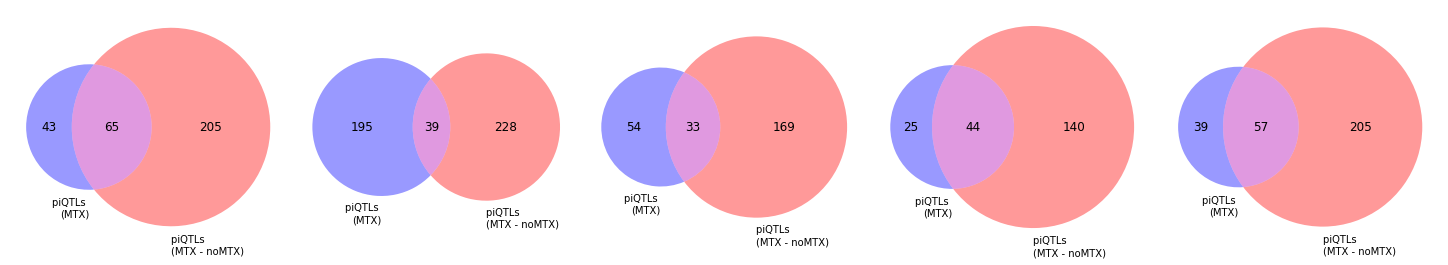

In [26]:
#### Overlapping analysis between v0 initial and final table
from matplotlib_venn import venn2


f, axes = plt.subplots(figsize=(20,6), ncols=5, constrained_layout=True)
i = 0
for DRUG in np.unique(final_piQTLs_with_MTX_and_media_masking_v0['DRUG']):
    Drug_v0 = final_piQTLs_with_MTX_and_media_masking_v0[final_piQTLs_with_MTX_and_media_masking_v0['DRUG'] == DRUG].reset_index(drop=True)
    Drug_v1 = final_piQTLs_with_MTX_and_media_masking[final_piQTLs_with_MTX_and_media_masking['DRUG'] == DRUG].reset_index(drop=True)

    venn = venn2([set(Drug_v0['PPI_lead_SNP']), set(Drug_v1['PPI_lead_SNP'])], ('piQTLs \n(MTX)', 'piQTLs \n(MTX - noMTX)'), set_colors=['blue', 'red'], alpha=0.4, ax=axes[i])

    # Increase the size of the labels
    for text in venn.set_labels:
        text.set_fontsize(10)  # Adjust the font size as needed

    for text in venn.subset_labels:
        text.set_fontsize(12)  # Adjust the font size as needed
    i += 1

plt.show()


___

In [ ]:
## Build table for website
website_table = final_piQTLs_with_MTX_and_media_masking

___

## QTL forward scan

In [ ]:
f = open('./run_QTL_scan_0.50_final_piQTLs.txt', 'w')
for CDT in np.unique(piQTLs_with_MTX_and_media_masking['gene']):
    TMP = piQTLs_with_MTX_and_media_masking[piQTLs_with_MTX_and_media_masking['gene'] == CDT]
    for block in np.unique(TMP['LD_b050']):
        QTL = TMP[TMP['LD_b050'] == block].sort_values('-log10_P', ascending=False).reset_index(drop=True)
        if len(QTL) > 1: 
            block_SNP_start = block.split('_')[0]
            block_SNP_end = block.split('_')[-1]
            top_SNP = QTL['SNP'].iloc[0]
            f.write(f'Rscript run_QTL_forward_scan.R {block_SNP_start} {block_SNP_end} {top_SNP} {CDT}\n')

f.close()

In [85]:
folder_path = '../../results/QTL_scan/results_0.50_final_piQTLs/'

all_rescued_piQTL_results = [ pd.read_csv(os.path.join(folder_path, table), sep='\t') for table in tqdm(os.listdir(folder_path))]

100%|██████████| 551/551 [00:00<00:00, 1207.56it/s]


In [ ]:

FORWARD_SCAN = pd.concat(all_rescued_piQTL_results).reset_index(drop=True)
FORWARD_SCAN_MASKED = FORWARD_SCAN[~FORWARD_SCAN['SNP'].isin(all_SNPs_to_mask)]

In [87]:
RESCUED_piQTLs = FORWARD_SCAN_MASKED[FORWARD_SCAN_MASKED['FDR'] < 0.05].merge(snps_annotations, on='SNP')
RESCUED_piQTLs['PPI'] = [ f"{RESCUED_piQTLs['gene'][idx].split('_')[0]}_{RESCUED_piQTLs['gene'][idx].split('_')[1]}" for idx in RESCUED_piQTLs.index ]
RESCUED_piQTLs['DRUG'] = [ RESCUED_piQTLs['gene'][idx].split('_')[3] for idx in RESCUED_piQTLs.index ]
RESCUED_piQTLs['-log10_P'] = - np.log10(RESCUED_piQTLs['p-value'])

RESCUED_piQTLs = RESCUED_piQTLs.sort_values('-log10_P', ascending=False).drop_duplicates(subset=['PPI','DRUG','LD_b050']).sort_values(['SNP', 'PPI', 'DRUG'])[['SNP', 'PPI', 'DRUG', 'CHR', 'position', '-log10_P', 'FDR', 'locus_id', 'gene_locus', 'gene_name', 'LD_b050', 'gene']] #.groupby('gene').count() # .to_csv('./rescued_piQTLs_LD_050.csv', index=False)

In [88]:
RESCUED_piQTLs

,SNP,PPI,DRUG,CHR,position,-log10_P,FDR,locus_id,gene_locus,gene_name,LD_b050,gene
38,646,TPO1_TCB2,Fluconazole,2,530047,1.727059,0.034504,YBR142W,YBR142W,MAK5,646_647_648_649,TPO1_TCB2_MTX_Fluconazole_avg_logratio_Fitness...
16,9419,ERV25_UIP4,Fluconazole,14,214248,3.111680,0.008053,YNL233W,YNL233W,BNI4,9403_9404_9405_9406_9407_9408_9409_9410_9411_9...,ERV25_UIP4_MTX_Fluconazole_avg_logratio_Fitnes...
0,9419,PMC1_GTR2,Fluconazole,14,214248,3.736859,0.004378,YNL233W,YNL233W,BNI4,9403_9404_9405_9406_9407_9408_9409_9410_9411_9...,PMC1_GTR2_MTX_Fluconazole_avg_logratio_Fitness...
40,10186,ADE17_PGM2,5-FC,15,170347,3.831679,0.003536,CUT362,NaN,NaN,10179_10180_10181_10182_10183_10184_10185_1018...,ADE17_PGM2_MTX_5-FC_avg_logratio_Fitness_minus...


In [89]:
from_forward_scan = []
for SNP, CDT, LD_block in RESCUED_piQTLs[RESCUED_piQTLs['FDR'] < 0.05][['SNP', 'gene', 'LD_b050']].values :
    print(SNP)
    TMP = final_piQTLs_with_MTX_and_media_masking[final_piQTLs_with_MTX_and_media_masking['SNP'] == SNP]
    TABLE = TMP[TMP['SNP'] == SNP][['SNP', 'CHR', 'position', 'p-value', 'FDR', 'name', 'snps_class_up']]
    try: 
        FDR = TMP[TMP['SNP'] == SNP]['FDR'].values[0]
        if FDR < 0.05 :
            from_forward_scan.append(TMP[TMP['SNP'] == SNP])
    except : 
        TRUE_LEAD_SNP = final_piQTLs_with_MTX_and_media_masking[(final_piQTLs_with_MTX_and_media_masking['gene'] == CDT) & (final_piQTLs_with_MTX_and_media_masking['LD_b050'] == LD_block)]
        display(TRUE_LEAD_SNP[['SNP', 'PPI', 'DRUG', 'CHR', 'position', '-log10_P', 'FDR', 'locus_id', 'gene_locus', 'gene_name', 'LD_b050', 'gene']])
            

646


,SNP,PPI,DRUG,CHR,position,-log10_P,FDR,locus_id,gene_locus,gene_name,LD_b050,gene
56,649,TPO1_TCB2,Fluconazole,2,538990,5.430028,0.001261,YBR148W,YBR148W,YSW1,646_647_648_649,TPO1_TCB2_MTX_Fluconazole_avg_logratio_Fitness...


9419


,SNP,PPI,DRUG,CHR,position,-log10_P,FDR,locus_id,gene_locus,gene_name,LD_b050,gene
82,9430,ERV25_UIP4,Fluconazole,14,228904,5.262844,0.00182,YNL222W_NFR/NDR,YNL222W,SSU72,9403_9404_9405_9406_9407_9408_9409_9410_9411_9...,ERV25_UIP4_MTX_Fluconazole_avg_logratio_Fitnes...


9419


,SNP,PPI,DRUG,CHR,position,-log10_P,FDR,locus_id,gene_locus,gene_name,LD_b050,gene
549,9427,PMC1_GTR2,Fluconazole,14,220803,4.094209,0.022214,YNL228W,YNL228W,YNL228W,9403_9404_9405_9406_9407_9408_9409_9410_9411_9...,PMC1_GTR2_MTX_Fluconazole_avg_logratio_Fitness...


10186


,SNP,PPI,DRUG,CHR,position,-log10_P,FDR,locus_id,gene_locus,gene_name,LD_b050,gene
486,10190,ADE17_PGM2,5-FC,15,171150,4.172007,0.018957,YOL081W,YOL081W,IRA2,10179_10180_10181_10182_10183_10184_10185_1018...,ADE17_PGM2_MTX_5-FC_avg_logratio_Fitness_minus...


In [90]:
gene_annotations = pd.read_csv('../../data/genome_annotations/sgd_database/orf_coding_R64-3-1.csv').rename(columns={"name":"Gene", "chrom":"Chrom", "start":"Start", "end":"End", "genome_annotations":"Coding"}) 

In [91]:
gene_annotations[gene_annotations['Gene'].isin(['MAK5','YSW1'])]

,locus_id,Gene,sgd_id,Coding,Chrom,Start,End,description,genome_version
407,YBR142W,MAK5,SGDID:S000000346,Verified ORF,CHR_2,528317,530638,"""Essential nucleolar protein; putative DEAD-bo...",Genome Release 64-3-1
413,YBR148W,YSW1,SGDID:S000000352,Verified ORF,CHR_2,537876,539705,"""Protein required for normal prospore membrane...",Genome Release 64-3-1


____

## Figure 2 - piQTL distribution

In [68]:
def effect_size_range_plot(piQTLs):
    sns.set_theme(style="ticks")
    CM = 1/2.54 # centimeters in inches
    
    class_color = {
        'ORF':'blue',
        'Close to 3\'-UTR':'orange',
        'Promoter':'green',
        'Unstable transcript': 'red',
        # 'CUT':'red',
        # 'SUT':'salmon',
        # 'XUT':'pink',
        'Other features':'purple',
        }

    f, axes = plt.subplots(figsize=(30 * CM, 6 * CM), nrows=1, ncols=5, sharey=True, sharex=True)
    i = 0
    piQTLs = piQTLs.replace('Intergenic region', 'Other features')
    piQTLs = piQTLs.replace('Non-coding RNA', 'Other features')
    for DRUG in ['noDrug', 'Fluconazole', '5-FC', 'Metformin', 'Trifluoperazine' ]:
        T = piQTLs[piQTLs['DRUG'].str.contains(DRUG)].reset_index(drop=True)
        T['abs_Effect_Size'] = np.abs(T['beta'])
        
        for CLASS in np.unique(T['snps_class_up']):
            TMP = T[T['snps_class_up'] == CLASS].sort_values('abs_Effect_Size', ascending=True).reset_index(drop=True)
            sns.scatterplot(y=TMP['abs_Effect_Size'], x=TMP.index, marker='.', linewidth=0, alpha = 0.6, color=class_color[CLASS], ax=axes[i])
            axes[i].set_ylim((0, 2))
            axes[i].set_ylabel('Absolute Effect Size')
            # axes[i].set_xticks(np.arange(10,110,30))
            axes[i].set_xscale('log')
            axes[i].set_title(DRUG)
        i += 1

    custom = [Line2D([], [], marker='.', color='blue', linestyle='None'),
            Line2D([], [], marker='.', color='orange', linestyle='None'),
            Line2D([], [], marker='.', color='green', linestyle='None'), 
            Line2D([], [], marker='.', color='red', linestyle='None'),
            # Line2D([], [], marker='.', color='salmon', linestyle='None'),
            # Line2D([], [], marker='.', color='pink', linestyle='None'),
            Line2D([], [], marker='.', color='purple', linestyle='None')]

    plt.legend(custom, ['ORF', 'Close to 3\'-UTR', 'Promoter', 'Unstable transcript', 'Other features'], bbox_to_anchor=(1.0, 1.0), loc='upper left')
    plt.tight_layout(rect=[0, 0, 0.85, 1])

    f.savefig('../../figures/figure_2/revised_figure_2_top_panel_LD_0.50_final_piQTLs.eps', dpi=300)
    # f.savefig('../../figures/figure_2/revised_figure_2_top_panel_LD_0.50_final_piQTLs.pdf', dpi=300)

def fraction_plot(piQTLs):
    sns.set_theme(style="ticks")
    total_by_class = pd.DataFrame(snps_annotations.groupby(['snps_class_up']).count()['SNP']).reset_index()

    fraction = pd.DataFrame(piQTLs.groupby(['DRUG', 'snps_class_up']).count()['SNP']).reset_index()
    fraction['DRUG'] = pd.Categorical(fraction['DRUG'], categories=['noDrug', 'Fluconazole', '5-FC', 'Metformin', 'Trifluoperazine'], ordered=True)
    fraction = fraction.merge(total_by_class, on=['snps_class_up'], suffixes=['_frac', '_total'])
    fraction['snps_class_up'] = pd.Categorical(fraction['snps_class_up'], categories=['ORF', 'Close to 3\'-UTR', 'Promoter', 'Unstable transcript', 'Other features'], ordered=True)
    fraction['frac'] = ((fraction['SNP_frac'] / 61) / fraction['SNP_total'])* 100
    fraction = fraction.sort_values(['snps_class_up', 'DRUG'])

    CM = 1/2.54 # centimeters in inches
    class_color = {
        'ORF':'blue',
        'Close to 3\'-UTR':'orange',
        'Promoter':'green',
        'Unstable transcript': 'red',
        # 'CUT':'red',
        # 'SUT':'salmon',
        # 'XUT':'pink',
        'Other features':'purple'
        }

    f = plt.figure(figsize=(15*CM, 15*CM))
    sns.barplot(y=fraction['frac'], x=fraction['DRUG'], hue=fraction['snps_class_up'], palette=['blue', 'orange', 'green', 'red', 'purple'])
    plt.xlabel('SNP class')
    plt.ylabel('piQTLs per PPI as % of SNPs per genomic feature')
    plt.xticks(rotation=30)
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))

    f.savefig('../../figures/figure_2/revised_figure_2_bottom_panel_LD_0.50_final_piQTLs.eps', dpi=300)
    # f.savefig('../../figures/figure_2/revised_figure_2_bottom_panel_LD_0.50_final_piQTLs.pdf', dpi=300)


In [69]:
final_piQTLs_with_MTX_and_media_masking[final_piQTLs_with_MTX_and_media_masking['snps_class_up'] == 'Other features']['locus_id']

85      YPRCdelta22
91        YCLWTy5-1
145     YPRCdelta22
146     YDRCdelta6a
206     YPRCdelta22
215     YPRCdelta22
231     YPRCdelta22
240     YPRCdelta22
298     YMRWdelta16
358     YPRCdelta22
374     YDRCdelta6a
382     YGLWdelta10
404       YCLWTy5-1
432     YGLWdelta10
489             HMR
504     YDRCdelta6a
507     YDRCdelta6a
509       YCLWTy5-1
574      YPLWdelta3
582     YPRCdelta22
615     YDRCdelta6a
635      YERWdelta9
656          ARS436
659     YDRCdelta6a
664     YPRCdelta22
707     YDRCdelta6a
715     YPRCdelta22
785     YMRWdelta16
811          TEL14L
851          ARS606
871     YMRWdelta16
876           CEN13
906          TEL14L
933     YPRCdelta22
1037    YPRCdelta22
1063    YDRCdelta6a
1098      YDRWTy2-2
1115    YMRWdelta16
1145     YERWdelta9
1146    YPRCdelta22
1158         TEL14L
1165            HMR
Name: locus_id, dtype: object

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


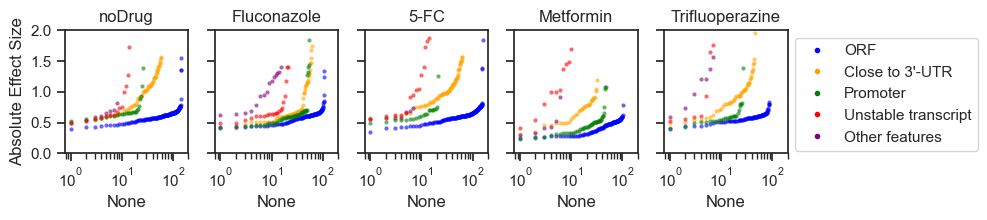

In [71]:
effect_size_range_plot(final_piQTLs_with_MTX_and_media_masking)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


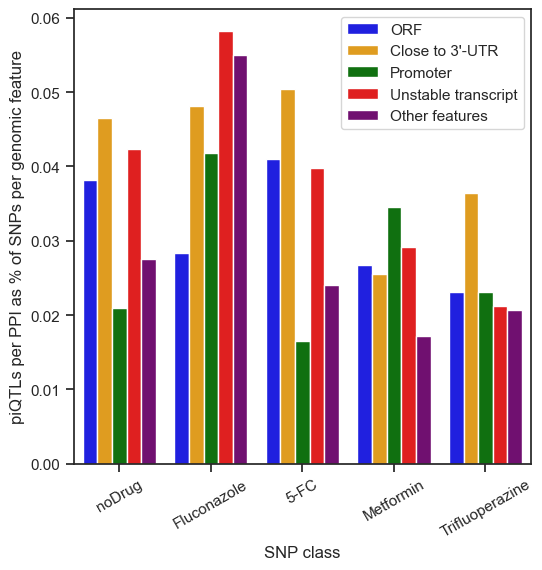

In [72]:
fraction_plot(final_piQTLs_with_MTX_and_media_masking)

___

## Figure 3 - cis. vs trans. piQTLs


In [73]:
GENE_COORDINATES = pd.read_csv('../../data/genome_annotations/sgd_database/orf_coding_R64-3-1.csv')
GENE_COORDINATES['chrom'] = [ GENE_COORDINATES['chrom'][idx].replace('_', '').replace('1000', 'MT') for idx in GENE_COORDINATES.index ]

In [74]:
PPI_list = pd.read_csv('../../data/pipeline/PPI_reference_barcodes.csv')
PPI_list['PPI_bait'] =  [ PPI_list['PPI'][idx].split('_')[0] for idx in PPI_list.index ]
PPI_list['PPI_prey'] =  [ PPI_list['PPI'][idx].split('_')[1] for idx in PPI_list.index ]

In [75]:
def get_piQTL_distance(idx, all_final_piQTLs):
    BAIT = all_final_piQTLs['gene'][idx].split('_')[0]
    BAIT_INFO = GENE_COORDINATES[GENE_COORDINATES['name'] == BAIT]
    BAIT_CHR = BAIT_INFO['chrom'].values[0]
    BAIT_START = BAIT_INFO['start'].values[0]
    BAIT_END = BAIT_INFO['end'].values[0]

    PREY = all_final_piQTLs['gene'][idx].split('_')[1]
    PREY_INFO = GENE_COORDINATES[GENE_COORDINATES['name'] == PREY]
    PREY_CHR = PREY_INFO['chrom'].values[0]
    PREY_START = PREY_INFO['start'].values[0]
    PREY_END = PREY_INFO['end'].values[0]

    SNP_CHR = f"CHR{all_final_piQTLs['CHR'][idx]}"
    SNP_POS = all_final_piQTLs['position'][idx]


    if SNP_CHR == BAIT_CHR :
        if (SNP_POS > BAIT_START) & (SNP_POS < BAIT_END):
            return 'cis'
        elif (np.absolute(BAIT_START - SNP_POS) < 1000) or (np.absolute(SNP_POS - BAIT_END) < 200) :
            return 'cis'
        else : 
            return 'trans'
    if SNP_CHR == PREY_CHR :
        if (SNP_POS > PREY_START) & (SNP_POS < PREY_END):
            return 'cis'
        elif (np.absolute(PREY_START - SNP_POS) < 1000) or (np.absolute(SNP_POS - PREY_END) < 200) :
            return 'cis'
        else : 
            return 'trans'
    else : 
        
        return 'trans'
    

def get_piQTL_distance_benchmarking(idx, limit, all_final_piQTLs):
    BAIT = all_final_piQTLs['gene'][idx].split('_')[0]
    BAIT_INFO = GENE_COORDINATES[GENE_COORDINATES['name'] == BAIT]
    BAIT_CHR = BAIT_INFO['chrom'].values[0]
    BAIT_START = int(BAIT_INFO['start'].values[0])
    BAIT_END = int(BAIT_INFO['end'].values[0])

    PREY = all_final_piQTLs['gene'][idx].split('_')[1]
    PREY_INFO = GENE_COORDINATES[GENE_COORDINATES['name'] == PREY]
    PREY_CHR = PREY_INFO['chrom'].values[0]
    PREY_START = int(PREY_INFO['start'].values[0])
    PREY_END = int(PREY_INFO['end'].values[0])

    SNP_CHR = f"CHR{all_final_piQTLs['CHR'][idx]}"
    SNP_POS = int(all_final_piQTLs['position'][idx])
    
    # print(BAIT, PREY)
    if SNP_CHR == BAIT_CHR :
        if (SNP_POS >= BAIT_START) & (SNP_POS <= BAIT_END):
            # print("CASE 1")
            return 'cis'
        elif (np.absolute(BAIT_START - SNP_POS) < limit ) or (np.absolute(SNP_POS - BAIT_END) < limit) :
            # print("CASE 2")
            return 'cis'
        else : 
                # print("CASE 5")
                return 'trans'
    if SNP_CHR == PREY_CHR :
        if (SNP_POS >= PREY_START) & (SNP_POS <= PREY_END):
            # print("CASE 3")
            return 'cis'
        elif (np.absolute(PREY_START - SNP_POS) < limit) or (np.absolute(SNP_POS - PREY_END) < limit) :
            # print("CASE 4")
            return 'cis'
        else : 
            # print("CASE 5")
            return 'trans'
    else: 
        return 'trans'

In [76]:
final_piQTLs_with_MTX_and_media_masking['cis/trans_custom'] = [ get_piQTL_distance(idx, final_piQTLs_with_MTX_and_media_masking) for idx in final_piQTLs_with_MTX_and_media_masking.index ]
final_piQTLs_with_MTX_and_media_masking['cis/trans_custom'] = pd.Categorical(final_piQTLs_with_MTX_and_media_masking['cis/trans_custom'] , categories=['cis', 'trans'], ordered=True)

for limit in tqdm([500, 1000, 2000, 5000, 10000, 20000, 25000, 30000, 40000]):
    final_piQTLs_with_MTX_and_media_masking[f'cis/trans_{limit}'] = [ get_piQTL_distance_benchmarking(idx, limit, final_piQTLs_with_MTX_and_media_masking) for idx in final_piQTLs_with_MTX_and_media_masking.index ]
    final_piQTLs_with_MTX_and_media_masking[f'cis/trans_{limit}'] = pd.Categorical(final_piQTLs_with_MTX_and_media_masking[f'cis/trans_{limit}'] , categories=['cis', 'trans'], ordered=True)

final_piQTLs_with_MTX_and_media_masking['DRUG'] = pd.Categorical(final_piQTLs_with_MTX_and_media_masking['DRUG'] , categories=['noDrug','Fluconazole','5-FC', 'Metformin', 'Trifluoperazine'], ordered=True)

100%|██████████| 9/9 [00:13<00:00,  1.50s/it]


In [77]:
final_piQTLs_with_MTX_and_media_masking[final_piQTLs_with_MTX_and_media_masking['cis/trans_5000'] == 'cis']

,SNP,gene,beta,t-stat,p-value,FDR,PPI,DRUG,-log10_P,chrom,...,cis/trans_custom,cis/trans_500,cis/trans_1000,cis/trans_2000,cis/trans_5000,cis/trans_10000,cis/trans_20000,cis/trans_25000,cis/trans_30000,cis/trans_40000
572,8522,ALO1_UIP4_MTX_Metformin_avg_logratio_Fitness_m...,-0.802114,-3.976052,0.000085,0.023275,ALO1_UIP4,Metformin,4.070974,CHR_13,...,trans,trans,trans,cis,cis,cis,cis,cis,cis,cis
573,4978,ERG11_ORM2_MTX_Fluconazole_avg_logratio_Fitnes...,0.497536,3.975840,0.000085,0.023292,ERG11_ORM2,Fluconazole,4.070603,CHR_8,...,trans,trans,cis,cis,cis,cis,cis,cis,cis,cis
643,4976,ERG11_PIS1_MTX_Fluconazole_avg_logratio_Fitnes...,0.491824,3.939232,0.000098,0.026431,ERG11_PIS1,Fluconazole,4.006892,CHR_8,...,trans,trans,cis,cis,cis,cis,cis,cis,cis,cis
796,4972,ERG11_HYR1_MTX_Fluconazole_avg_logratio_Fitnes...,0.465339,3.873654,0.000128,0.033073,ERG11_HYR1,Fluconazole,3.893968,CHR_8,...,cis,cis,cis,cis,cis,cis,cis,cis,cis,cis


/tmp/ipykernel_979937/2640622254.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  axes = final_piQTLs_with_MTX_and_media_masking[['cis/trans_custom', 'cis/trans_500', 'cis/trans_1000', 'cis/trans_2000', 'cis/trans_5000', 'cis/trans_10000', 'cis/trans_20000', 'cis/trans_25000', 'cis/trans_30000', 'cis/trans_40000']].apply(pd.value_counts).T.plot(kind='bar', color=['orange', 'cyan'])
/tmp/ipykernel_979937/2640622254.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  axes = final_piQTLs_with_MTX_and_media_masking[['cis/trans_custom', 'cis/trans_500', 'cis/trans_1000', 'cis/trans_2000', 'cis/trans_5000', 'cis/trans_10000', 'cis/trans_20000', 'cis/trans_25000', 'cis/trans_30000', 'cis/trans_40000']].apply(pd.value_counts).T.plot(kind='bar', color=['orange', 'cyan'])
/tmp/ipykernel_979937/2640622254.py:3: FutureW

<Figure size 393.701x393.701 with 0 Axes>

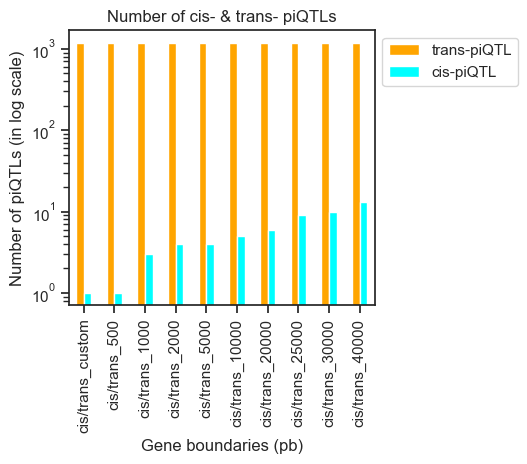

In [94]:
CM = 1/2.54 # centimeters in inches
f = plt.figure(figsize=(10*CM, 10*CM))
axes = final_piQTLs_with_MTX_and_media_masking[['cis/trans_custom', 'cis/trans_500', 'cis/trans_1000', 'cis/trans_2000', 'cis/trans_5000', 'cis/trans_10000', 'cis/trans_20000', 'cis/trans_25000', 'cis/trans_30000', 'cis/trans_40000']].apply(pd.value_counts).T.plot(kind='bar', color=['orange', 'cyan'])
plt.ylabel('Number of piQTLs (in log scale)')
plt.xlabel('Gene boundaries (pb)')
plt.yscale('log')
plt.xticks(rotation=90)
plt.legend(['trans-piQTL','cis-piQTL'], bbox_to_anchor=(1.0, 1.0),)
plt.title('Number of cis- & trans- piQTLs')
g = axes.get_figure()
g.tight_layout(rect=[0, 0, 0.85, 1])

g.savefig('../../figures/supp_figure_6/Figure_S6A_cis_vs_trans_piQTLs_definition_benchmarking.eps', dpi=300)
# g.savefig('../../figures/supp_figure_6/Figure_S6A_cis_vs_trans_piQTLs_definition_benchmarking.pdf', dpi=300)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/tmp/ipykernel_979937/2497821289.py:51: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pvalue = stats.kstest(T[T[f'cis/trans_{boundaries_definition}'] == 'cis']['beta'], T[T[f'cis/trans_{boundaries_definition}'] == 'trans']['beta'])
/tmp/ipykernel_979937/2497821289.py:51: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pvalue = stats.kstest(T[T[f'cis/trans_{boundaries_definition}'] == 'cis']['beta'], T[T[f'cis/trans_{boundaries_definition}'] == 'trans']['beta'])
/tmp/ipykernel_979937/2497821289.py:51: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pvalue = stats.kstest(T

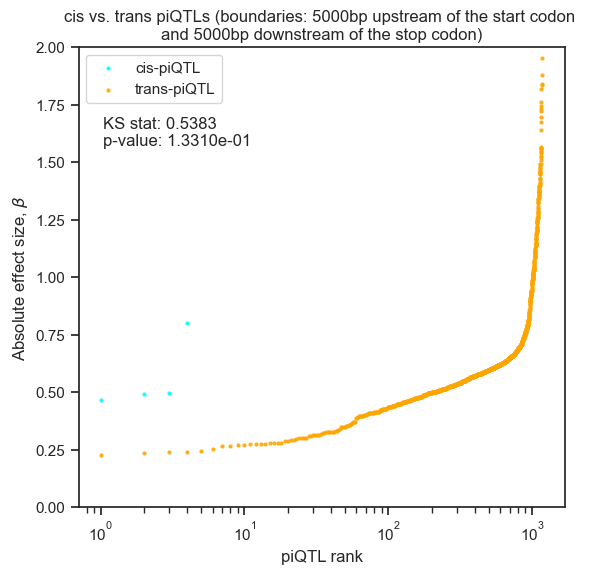

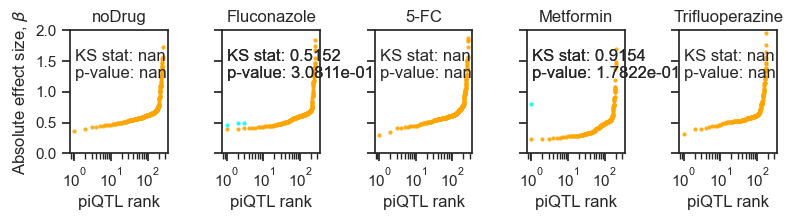

In [93]:
all_final_piQTLs = final_piQTLs_with_MTX_and_media_masking
# for limit in [custom, 500, 1000, 2000, 5000, 10000, 20000, 25000, 30000, 40000]:
boundaries_definition = '5000'
CM = 1/2.54 # centimeters in inches
all_final_piQTLs['abs_Effect_Size'] = np.abs(all_final_piQTLs['beta'])

f = plt.figure(figsize=(15*CM, 15*CM))
for TYPE in np.unique(all_final_piQTLs[f'cis/trans_{boundaries_definition}']):
    if 'cis' in TYPE :
        color = 'cyan'
    else : 
        color = 'orange'
    T = all_final_piQTLs[all_final_piQTLs[f'cis/trans_{boundaries_definition}'] == TYPE].sort_values('abs_Effect_Size', ascending=True).reset_index(drop=True)
    T['Rank'] = T.index + 1
    sns.scatterplot(y=T['abs_Effect_Size'], x=T['Rank'], marker='.', linewidth=0, alpha = 0.9, color=color)
    plt.ylim((0, 2))
    plt.xscale('log')
    plt.ylabel(r'Absolute effect size, $\beta$')
    plt.xlabel('piQTL rank')
    plt.title(f'cis vs. trans piQTLs (boundaries: {boundaries_definition}bp upstream of the start codon \nand {boundaries_definition}bp downstream of the stop codon)')
    plt.legend(['cis-piQTL','trans-piQTL'])
    plt.tight_layout()

stat, pvalue = stats.kstest(all_final_piQTLs[all_final_piQTLs[f'cis/trans_{boundaries_definition}'] == 'cis']['beta'], all_final_piQTLs[all_final_piQTLs[f'cis/trans_{boundaries_definition}'] == 'trans']['beta'])
annotation_text = f'KS stat: {stat:.4f}\np-value: {pvalue:.4e}'
plt.annotate(annotation_text, xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12,
             horizontalalignment='left', verticalalignment='top')
plt.tight_layout()

f.savefig(f'../../figures/figure_3/FIGURE_3A_{boundaries_definition}_limits_LD_050.eps', dpi=300)
# f.savefig(f'../../figures/figure_3/FIGURE_3A_{boundaries_definition}_limits_LD_050.pdf', dpi=300)

f, axes = plt.subplots(figsize=(24 * CM, 6 * CM), nrows=1, ncols=5, sharey=True, sharex=True)
i = 0
for DRUG in ['noDrug', 'Fluconazole', '5-FC', 'Metformin', 'Trifluoperazine']:
    T = all_final_piQTLs[all_final_piQTLs['gene'].str.contains(DRUG)].reset_index(drop=True)
    for TYPE in np.unique(T[f'cis/trans_{boundaries_definition}']):
        if 'cis' in TYPE :
            color = 'cyan'
        else : 
            color= 'orange'
        TMP = T[T[f'cis/trans_{boundaries_definition}'] == TYPE].sort_values('abs_Effect_Size', ascending=True).reset_index(drop=True)
        TMP['Rank'] = TMP.index + 1
        sns.scatterplot(y=TMP['abs_Effect_Size'], x=TMP['Rank'], marker='.', linewidth=0, alpha = 0.9, color=color, ax=axes[i])
        axes[i].set_ylim((0, 2))
        axes[i].set_xscale('log')
        axes[i].set_ylabel(r'Absolute effect size, $\beta$')
        axes[i].set_xlabel('piQTL rank')
        axes[i].set_title(DRUG)
        try: 
            stat, pvalue = stats.kstest(T[T[f'cis/trans_{boundaries_definition}'] == 'cis']['beta'], T[T[f'cis/trans_{boundaries_definition}'] == 'trans']['beta'])
            annotation_text = f'KS stat: {stat:.4f}\np-value: {pvalue:.4e}'
            axes[i].annotate(annotation_text, xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12,
                horizontalalignment='left', verticalalignment='top')
        except: 
            annotation_text = ''
    i += 1

plt.tight_layout(rect=[0, 0, 0.85, 1])

f.savefig(f'../../figures/supp_figure_6/FIGURE_S6B_{boundaries_definition}_limits_LD_050.eps', dpi=300)
# f.savefig(f'../../figures/supp_figure_6/FIGURE_S6B_{boundaries_definition}_limits_LD_050.pdf', dpi=300)


___

___

## Figure 5 - Non-coding RNAs

,UT_Type1,UT_Type2,t-test_stat,t-test_pvalue
0,ORF,ncRNA,-17.774418,2.547219e-56


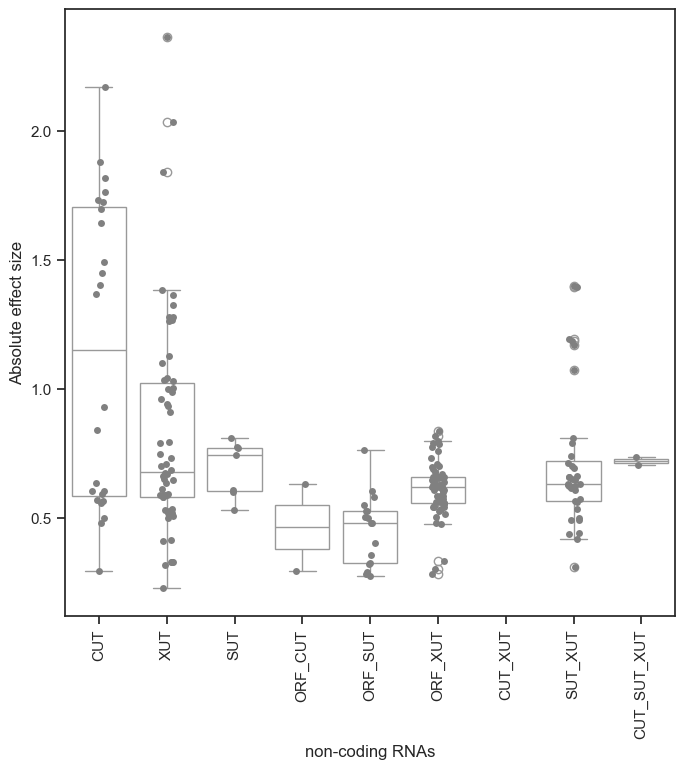

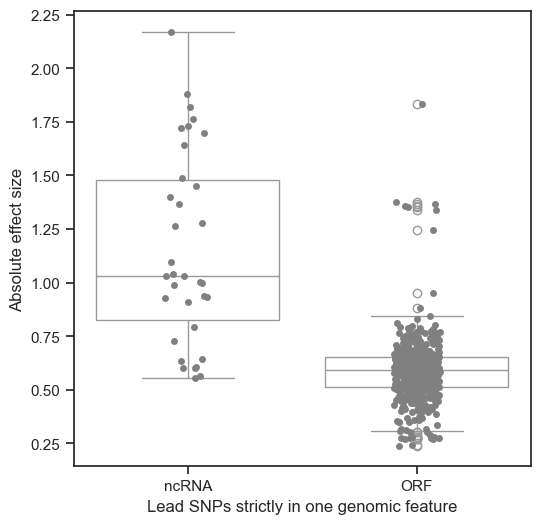

In [125]:
multiple_UTs = pd.read_csv('../../data/genotype_information/snps_annotations_genome-version-3-64-1_UTs.txt').rename(columns={"snp_id":"SNP"})

UT_piQTLs = all_final_piQTLs.merge(multiple_UTs, on='SNP')
UT_piQTLs['snps_annotations'] = pd.Categorical(UT_piQTLs['snps_annotations'] , categories=['CUT', 'XUT', 'SUT', 'ORF_CUT', 'ORF_SUT', 'ORF_XUT', 'CUT_XUT', 'SUT_XUT','CUT_SUT_XUT'], ordered=True)

f = plt.figure(figsize=(20*CM, 20*CM))

sns.boxplot(y=np.abs(UT_piQTLs['beta']), x=UT_piQTLs['snps_annotations'], color='white')
sns.stripplot(y=np.abs(UT_piQTLs['beta']), x=UT_piQTLs['snps_annotations'], color='grey')
plt.xlabel('non-coding RNAs')
plt.ylabel('Absolute effect size')
plt.xticks(rotation=90)

f.savefig('../../figures/figure_5/effect_size_boxplot_UTs_LD_0.50.eps', dpi=300)
# f.savefig('../../figures/figure_5/effect_size_boxplot_UTs_LD_0.50.pdf', dpi=300)

UT_piQTLs = all_final_piQTLs.merge(multiple_UTs, on='SNP')
snps_ncRNA_only = [2752, 3445, 9574, 10220, 10456, 11917, 11918]

UT_piQTLs = UT_piQTLs[UT_piQTLs['SNP'].isin(snps_ncRNA_only) | (UT_piQTLs['snps_annotations'] == 'ORF')].replace('CUT', 'ncRNA').replace('SUT', 'ncRNA').replace('XUT', 'ncRNA')
UT_piQTLs['snps_annotations'] = pd.Categorical(UT_piQTLs['snps_annotations'] , categories=['ncRNA', 'ORF'], ordered=True)

f = plt.figure(figsize=(15*CM, 15*CM))

sns.boxplot(y=np.abs(UT_piQTLs['beta']), x=UT_piQTLs['snps_annotations'], color='white')
sns.stripplot(y=np.abs(UT_piQTLs['beta']), x=UT_piQTLs['snps_annotations'], color='grey')
plt.xlabel('Lead SNPs strictly in one genomic feature')
plt.ylabel('Absolute effect size')

f.savefig('../../figures/figure_5/plot_strict_SNP_in_ncRNAs_vs_ORF.eps', dpi=300)
# # f.savefig('../../figures/figure_5/plot_strict_SNP_in_ncRNAs_vs_ORF.pdf', dpi=300)


UT_annotations_pairwaise_comparison = [] 

UTs_annotations = np.unique(UT_piQTLs['snps_annotations'].dropna())
for i in range(len(UTs_annotations)):
    for j in range(i+1, len(UTs_annotations)):
        A = UTs_annotations[i]
        B = UTs_annotations[j]

        effect_A = np.abs(UT_piQTLs[UT_piQTLs['snps_annotations'] == A]['beta'].values)
        effect_B = np.abs(UT_piQTLs[UT_piQTLs['snps_annotations'] == B]['beta'].values)

        stat, pval = stats.ttest_ind(effect_A,effect_B)
        UT_annotations_pairwaise_comparison.append([A, B, stat, pval])

pd.DataFrame(UT_annotations_pairwaise_comparison, columns=['UT_Type1', 'UT_Type2', 't-test_stat', 't-test_pvalue']).dropna() # .to_csv('./UT_annotations_t-tests_LD_050.csv', index=False)

_____

## Supplementary Figure 3 - LD benchmarking

In [98]:
LD_stats_piQTLs = []
LD_thresholds = [i / 20.0 for i in range(2, 21)]
for i in tqdm(LD_thresholds):
    LD_blocks = identify_ld_blocks(LD_table, i)
    
    piQTLs_fdr_filtered = eqtl_matrix_results_1[~(eqtl_matrix_results_1['gene'].str.contains('noPPI_reference')) & (eqtl_matrix_results_1['FDR'] < 0.05)].reset_index(drop=True)
    piQTLs_fdr_filtered['PPI'] = [ f"{piQTLs_fdr_filtered['gene'][idx].split('_')[0]}_{piQTLs_fdr_filtered['gene'][idx].split('_')[1]}" for idx in piQTLs_fdr_filtered.index ]
    piQTLs_fdr_filtered['DRUG'] = [ piQTLs_fdr_filtered['gene'][idx].split('_')[3] for idx in piQTLs_fdr_filtered.index ]
    piQTLs_fdr_filtered['-log10_P'] = - np.log10(piQTLs_fdr_filtered['p-value'])
        
    piQTLs_DRUG_MTX_BHT = piQTLs_fdr_filtered
    piQTLs_DRUG_MTX_BHT[f'LD_{i}'] = piQTLs_DRUG_MTX_BHT['SNP'].apply(inblock, args=(LD_blocks,))
    piQTLs_DRUG_MTX_BHT['PPI_block'] = [ f"{piQTLs_DRUG_MTX_BHT['PPI'][idx]}-{piQTLs_DRUG_MTX_BHT[f'LD_{i}'][idx]}" for idx in piQTLs_DRUG_MTX_BHT.index ]
    
    piQTLs_with_MTX_masking = piQTLs_DRUG_MTX_BHT[~piQTLs_DRUG_MTX_BHT['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
    ### All piQTLs (PPI & Drug -specific, one lead SNP per LD blocks)
    final_piQTLs_with_MTX_and_media_masking_for_benchmarking = piQTLs_with_MTX_masking.drop_duplicates(subset=['PPI','DRUG', f'LD_{i}'], keep='first').reset_index(drop=True)
    
    #### total piQTLs for all drugs (not average)" and then "total number of UNIQUE piQTL SNPs for all drugs (not averaged)" 
    ### Unique Blocks
    u_piQTLs = len(np.unique(final_piQTLs_with_MTX_and_media_masking_for_benchmarking[f'LD_{i}']))
    ### Unique SNPs
    u_SNPs = len(np.unique(final_piQTLs_with_MTX_and_media_masking_for_benchmarking['SNP']))

    LD_stats_piQTLs.append([i, len(final_piQTLs_with_MTX_and_media_masking_for_benchmarking), u_piQTLs, u_SNPs, len(final_piQTLs_with_MTX_and_media_masking_for_benchmarking )/(61*5)]) 

100%|██████████| 19/19 [01:16<00:00,  4.04s/it]


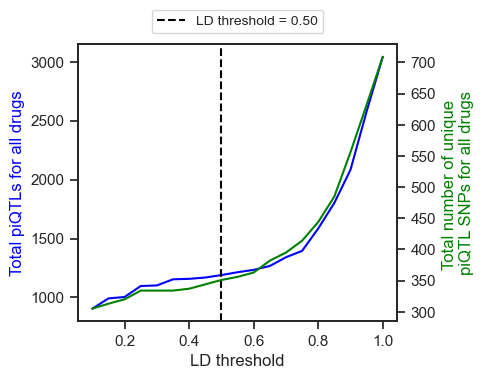

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming LD_benchmarks is a DataFrame and already loaded
LD_benchmarks = pd.DataFrame(LD_stats_piQTLs, columns=['LD_threshold', 'piQTLs','piQTLs_blocks', 'piQTLs_SNPs', 'piQTLs_per_PPI'])

fig, ax1 = plt.subplots(figsize=(5,4))
ax1.set_xlabel('LD threshold')

# Plot Total piQTLs for all drugs
ax1.plot(LD_benchmarks['LD_threshold'], LD_benchmarks['piQTLs'], color='blue')
ax1.set_ylabel('Total piQTLs for all drugs', color='blue')
ax1.tick_params(axis='y')

ax1.axvline(x=0.50, color='black', linestyle='--', label='LD threshold = 0.50')
ax1.legend(bbox_to_anchor=(0.5, 1.15), loc='upper center', fontsize=10, ncol=1)

# Plot Total number of unique piQTL SNPs for all drugs
ax2 = ax1.twinx()  
ax2.set_ylabel('Total number of unique \npiQTL SNPs for all drugs', color='green')
ax2.plot(LD_benchmarks['LD_threshold'], LD_benchmarks['piQTLs_SNPs'], color='green')
ax2.tick_params(axis='y')

plt.tight_layout()
plt.show()

# fig.savefig('../../figures/supp_figure_3/LD_benchmarking_V1.eps', dpi=300)
# fig.savefig('../../figures/supp_figure_3/LD_benchmarking_V1.pdf', dpi=300)


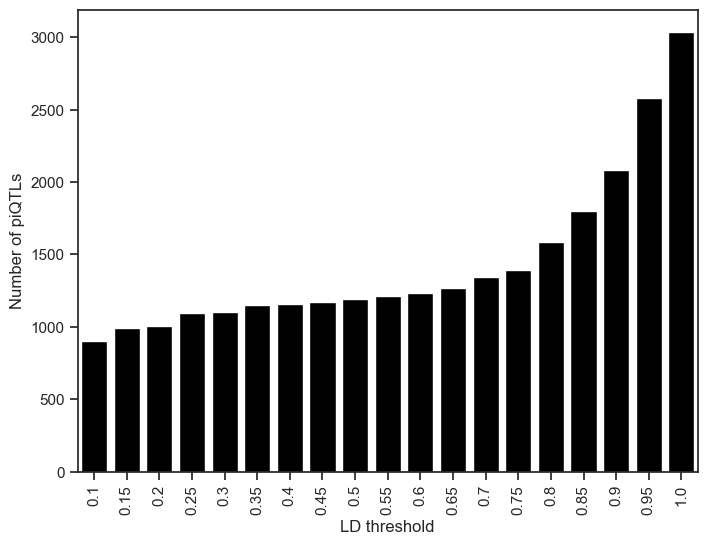

In [ ]:
f = plt.figure(figsize=(8,6))
sns.barplot(x=LD_benchmarks['LD_threshold'], y=LD_benchmarks['piQTLs'], color='black')
plt.ylabel('Number of piQTLs')
plt.xlabel('LD threshold')
plt.xticks(rotation=90)

f.savefig('../../figures/supp_figure_3/LD_benchmarking_V2.eps', dpi=300)
# f.savefig('../../figures/supp_figure_3/LD_benchmarking_V2.pdf', dpi=300)

___

## Heatmaps 

In [101]:
final_piQTLs_with_MTX_and_media_masking

,SNP,gene,beta,t-stat,p-value,FDR,PPI,DRUG,-log10_P,chrom,...,cis/trans_500,cis/trans_1000,cis/trans_2000,cis/trans_5000,cis/trans_10000,cis/trans_20000,cis/trans_25000,cis/trans_30000,cis/trans_40000,abs_Effect_Size
0,8799,ERG11_ORM2_MTX_Metformin_avg_logratio_Fitness_...,0.412412,5.955680,6.232370e-09,0.000003,ERG11_ORM2,Metformin,8.205347,CHR_13,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,0.412412
1,10438,SSH1_ORM2_MTX_noDrug_avg_logratio_Fitness_minu...,-1.424358,-5.824198,1.286408e-08,0.000006,SSH1_ORM2,noDrug,7.890621,CHR_15,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,1.424358
2,8792,ERG11_ORM2_MTX_Metformin_avg_logratio_Fitness_...,0.400424,5.759528,1.828869e-08,0.000008,ERG11_ORM2,Metformin,7.737817,CHR_13,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,0.400424
3,8810,ERG11_ORM2_MTX_Metformin_avg_logratio_Fitness_...,0.401647,5.665284,3.037285e-08,0.000013,ERG11_ORM2,Metformin,7.517515,CHR_13,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,0.401647
4,10438,ERV25_ORM2_MTX_noDrug_avg_logratio_Fitness_min...,-1.216292,-5.546540,5.701815e-08,0.000023,ERV25_ORM2,noDrug,7.243987,CHR_15,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,1.216292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,3951,ERG11_HYR1_MTX_Fluconazole_avg_logratio_Fitnes...,-0.448171,-3.747808,2.081572e-04,0.049850,ERG11_HYR1,Fluconazole,3.681609,CHR_7,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,0.448171
1181,7430,RET2_EMP47_MTX_Fluconazole_avg_logratio_Fitnes...,1.023427,3.747496,2.084062e-04,0.049895,RET2_EMP47,Fluconazole,3.681089,CHR_12,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,1.023427
1182,10482,ERG11_TPO4_MTX_Fluconazole_avg_logratio_Fitnes...,-0.487098,-3.747432,2.084567e-04,0.049904,ERG11_TPO4,Fluconazole,3.680984,CHR_15,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,0.487098
1183,9430,DHH1_LSM3_MTX_Fluconazole_avg_logratio_Fitness...,-0.582861,-3.747327,2.085409e-04,0.049921,DHH1_LSM3,Fluconazole,3.680809,CHR_14,...,trans,trans,trans,trans,trans,trans,trans,trans,trans,0.582861


In [102]:
DRUG_PPI_SNPs = []

for DRUG in np.unique(final_piQTLs_with_MTX_and_media_masking['DRUG']):
    DRUG_TABLE = final_piQTLs_with_MTX_and_media_masking[final_piQTLs_with_MTX_and_media_masking['DRUG'] == DRUG]
    for PPI, SNP in DRUG_TABLE[['PPI','SNP']].values : 
        DRUG_PPI_SNPs.append([DRUG, PPI, SNP])

DRUG_PPI_SNPs_ALL = pd.DataFrame(DRUG_PPI_SNPs, columns=['DRUG', 'PPI', 'SNP'])
NODRUG_SNPs_ALL = DRUG_PPI_SNPs_ALL[DRUG_PPI_SNPs_ALL['DRUG'] == 'noDrug']

In [103]:
all_final_piQTLs = final_piQTLs_with_MTX_and_media_masking

def which_piQTL_are_you(idx, no_DRUG_SNPs):
    PPI = all_final_piQTLs['PPI'][idx]
    DRUG = all_final_piQTLs['DRUG'][idx]
    SNP = all_final_piQTLs['SNP'][idx]

    if DRUG == 'noDrug':
        return np.nan 
    
    else : 
        is_in_noDrug = no_DRUG_SNPs[(no_DRUG_SNPs['PPI'] == PPI) & (no_DRUG_SNPs['SNP'] == SNP)]
        if len(is_in_noDrug) == 1 :
            return 2 
        else : 
            return 1


In [104]:
all_final_piQTLs['Heatmap'] = [ which_piQTL_are_you(idx, NODRUG_SNPs_ALL) for idx in all_final_piQTLs.index ] 

In [106]:
f = open('../../results/06_networks/PPI_similarity_network_order.txt', 'r')
PPI_network_order = [ line.strip() for line in f.readlines() ]
f.close()

for i  in range(len(PPI_network_order)):
    PPI = PPI_network_order[i].replace(':','_')
    if PPI not in np.unique(all_final_piQTLs['PPI'].values):
        PPI_reversed = f"{PPI.split('_')[1]}_{PPI.split('_')[0]}"
        PPI_network_order[i] = PPI_reversed.replace('_',':')
    else:
        PPI_network_order[i] = PPI.replace('_',':')

In [107]:
def get_heatmap(all_final_piQTLs, DRUG, width, height):
    Heatmap = all_final_piQTLs[all_final_piQTLs['DRUG'] == DRUG].reset_index(drop=True)
    
    all_snps_across_PPI = [] 
    for PPI in sorted(np.unique(Heatmap['PPI'])):
        PPI_TABLE = Heatmap[Heatmap['PPI'] == PPI]         
        for SNP in sorted(np.unique(Heatmap['SNP'])):
            if SNP in PPI_TABLE['SNP'].values:
                heatmap_val = PPI_TABLE[PPI_TABLE['SNP'] == SNP]['Heatmap'].values[0]
                all_snps_across_PPI.append([PPI.replace('_',':'), SNP, heatmap_val])
            else: 
                all_snps_across_PPI.append([PPI.replace('_',':'), SNP, 0])

    Heatmap_df = pd.DataFrame(all_snps_across_PPI, columns=['PPI', 'SNP', 'Heatmap']).set_index('PPI')
    # Pivot the DataFrame
    Heatmap_pivot = Heatmap_df.pivot_table(values='Heatmap', index='PPI', columns='SNP')

    Heatmap_pivot = Heatmap_pivot.reindex(PPI_network_order).replace(np.nan,0)
    
    sns.set(style="ticks")
    f = plt.figure(figsize=(width,height))
    sns.heatmap(Heatmap_pivot, xticklabels=True, yticklabels=True, cmap=['black', 'yellow', 'cyan'], linewidths=0.2, linecolor='gray', cbar=True, cbar_kws={"label": "Type of piQTLs"})
    plt.title(DRUG)
    f.savefig(f'../../figures/heatmaps/{DRUG}_heatmap_LD_050.eps', dpi=300)
    # f.savefig(f'../../figures/heatmaps/{DRUG}_heatmap_LD_050.pdf', dpi=300)
    return Heatmap_pivot

SNP,6,254,260,264,268,537,551,556,575,598,...,11926,11927,11928,11929,11931,11935,11938,11940,11942,11946
PPI,,,,,,,,,,,,,,,,,,,,,
GTR1:SLM4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:EMP70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:SNA3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:EMP47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PMC1:CTR2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ADE17:GIS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HUG1:ADE17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADE17:PGM2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


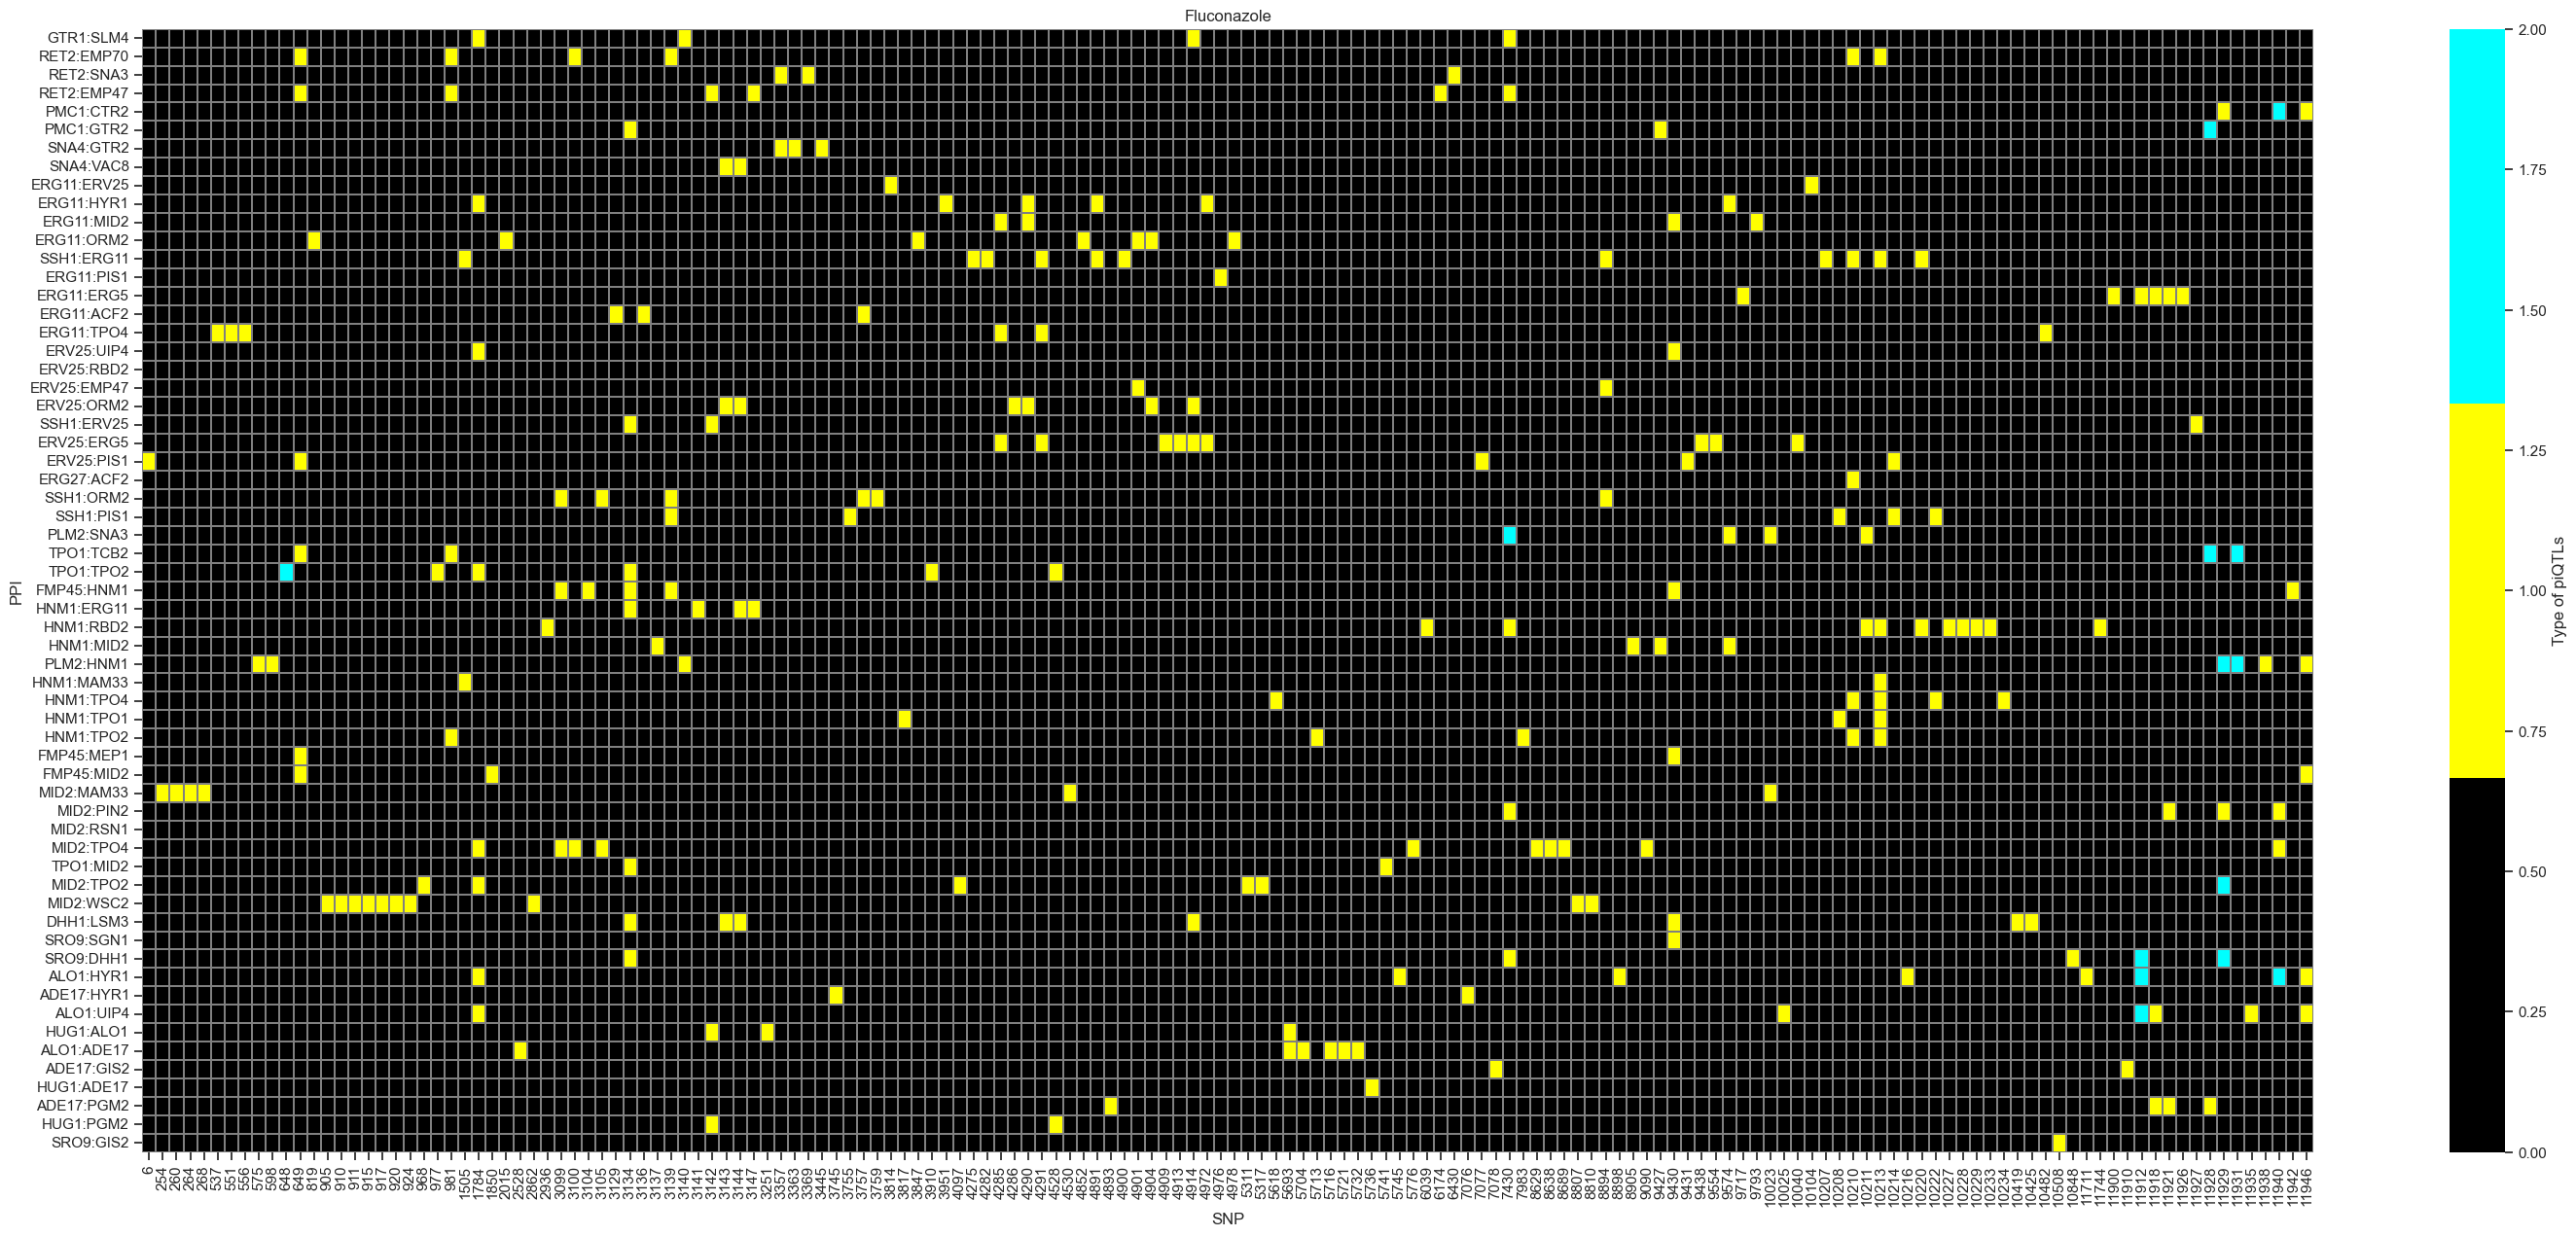

In [109]:
get_heatmap(all_final_piQTLs, 'Fluconazole', 36, 15)

SNP,51,82,265,277,282,649,1093,1095,1099,1142,...,11920,11927,11928,11929,11931,11935,11940,11942,11944,11946
PPI,,,,,,,,,,,,,,,,,,,,,
GTR1:SLM4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:EMP70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:SNA3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:EMP47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PMC1:CTR2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ADE17:GIS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HUG1:ADE17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADE17:PGM2,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


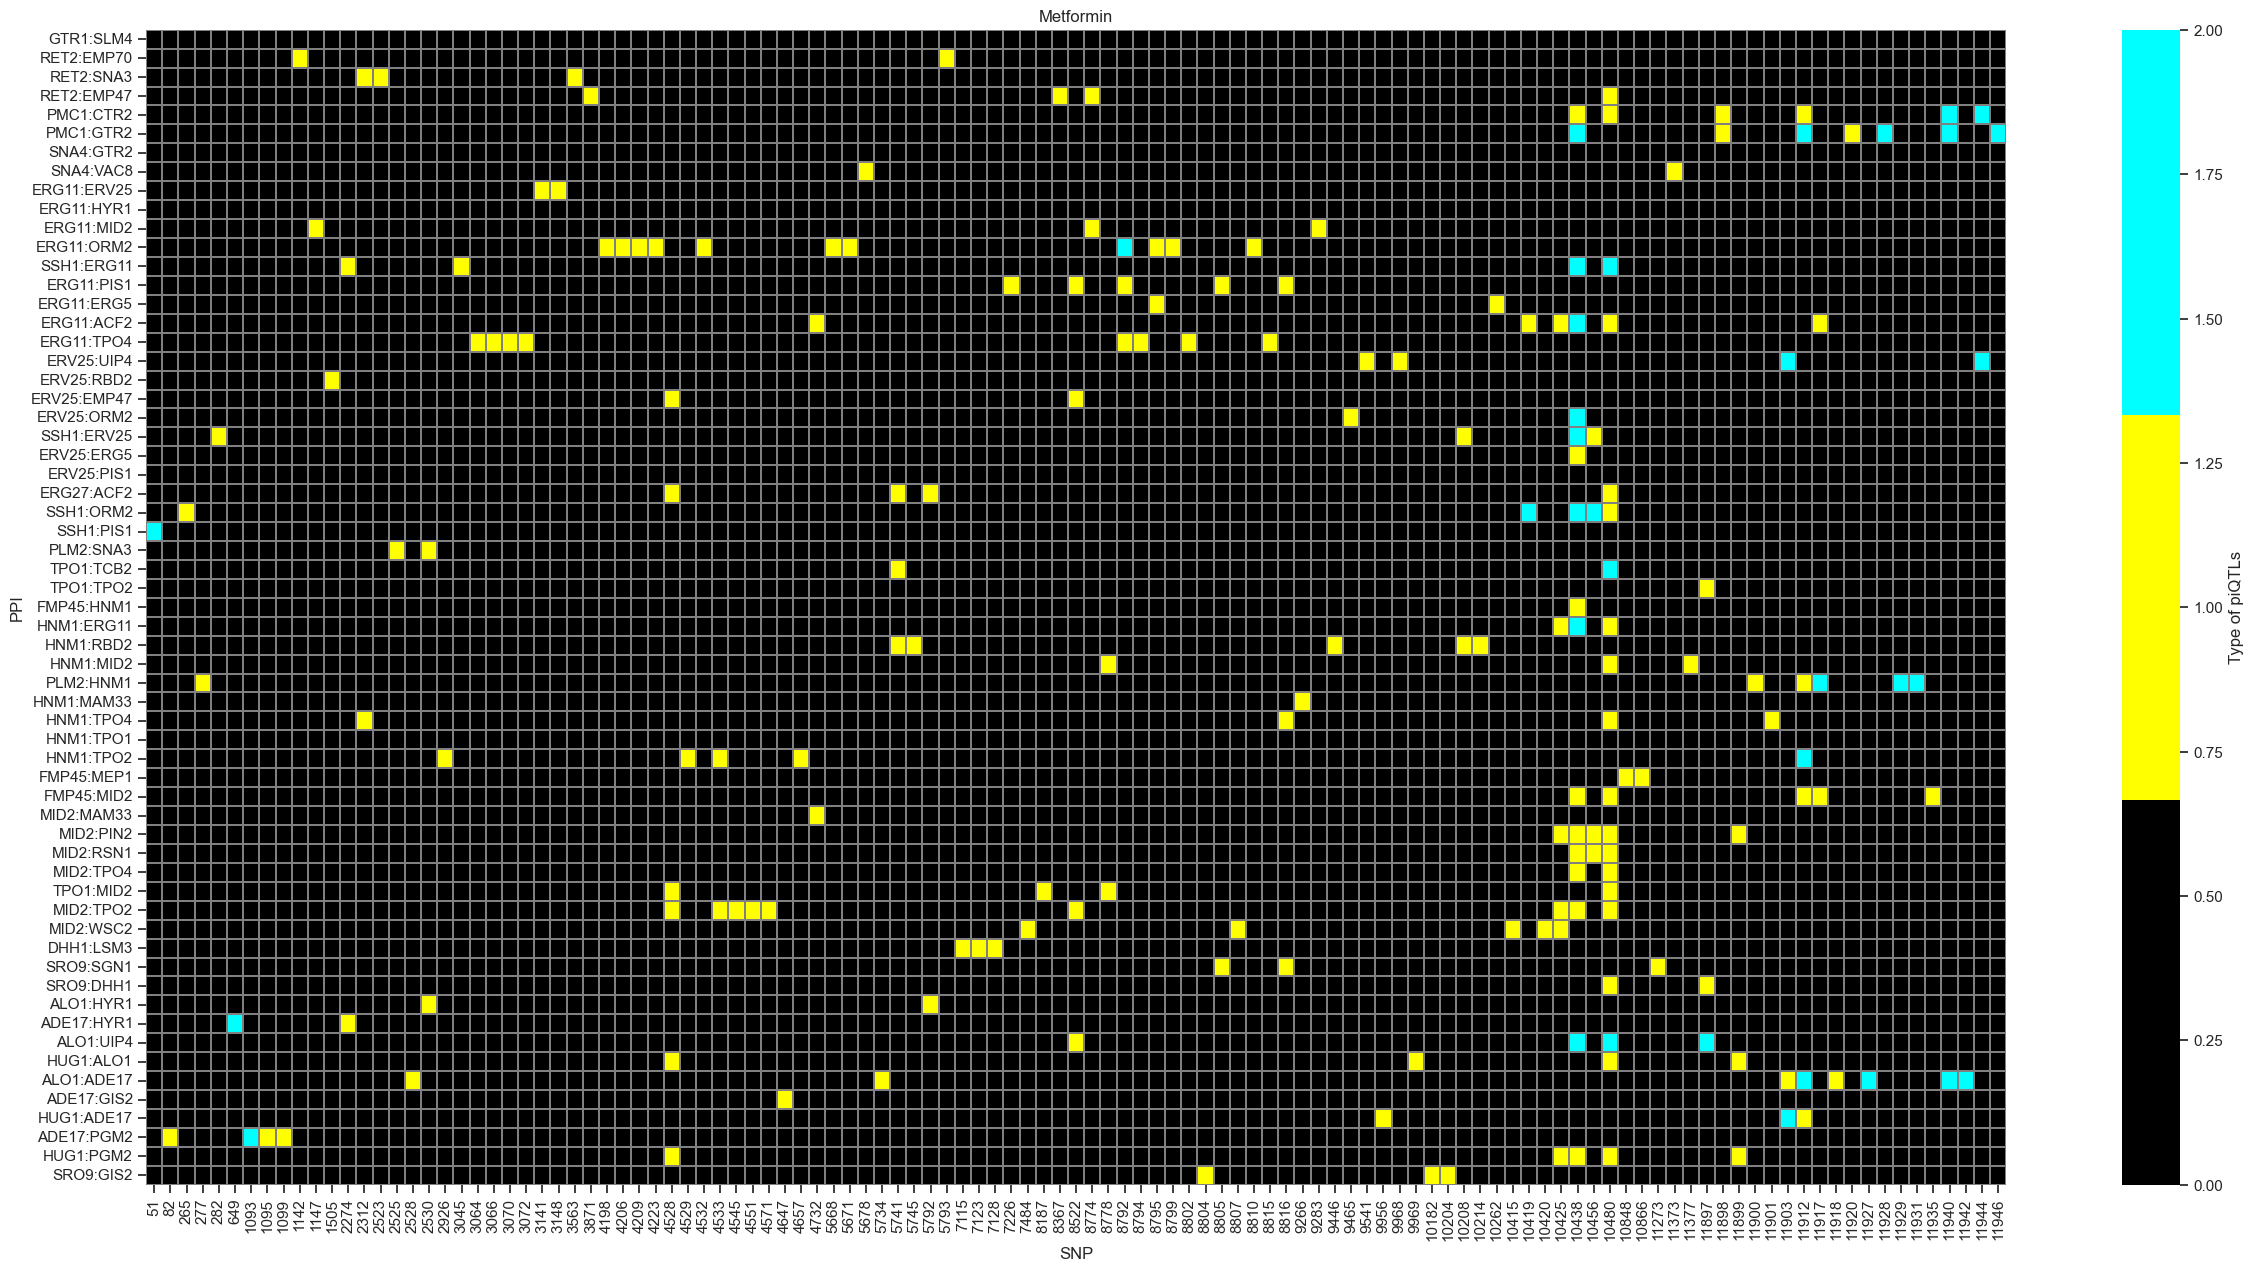

In [110]:
get_heatmap(all_final_piQTLs, 'Metformin', 30, 15)

SNP,51,282,527,653,654,667,779,789,792,798,...,11929,11931,11932,11940,11942,11943,11944,11945,11946,11948
PPI,,,,,,,,,,,,,,,,,,,,,
GTR1:SLM4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:EMP70,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:SNA3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:EMP47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PMC1:CTR2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ADE17:GIS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HUG1:ADE17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0
ADE17:PGM2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


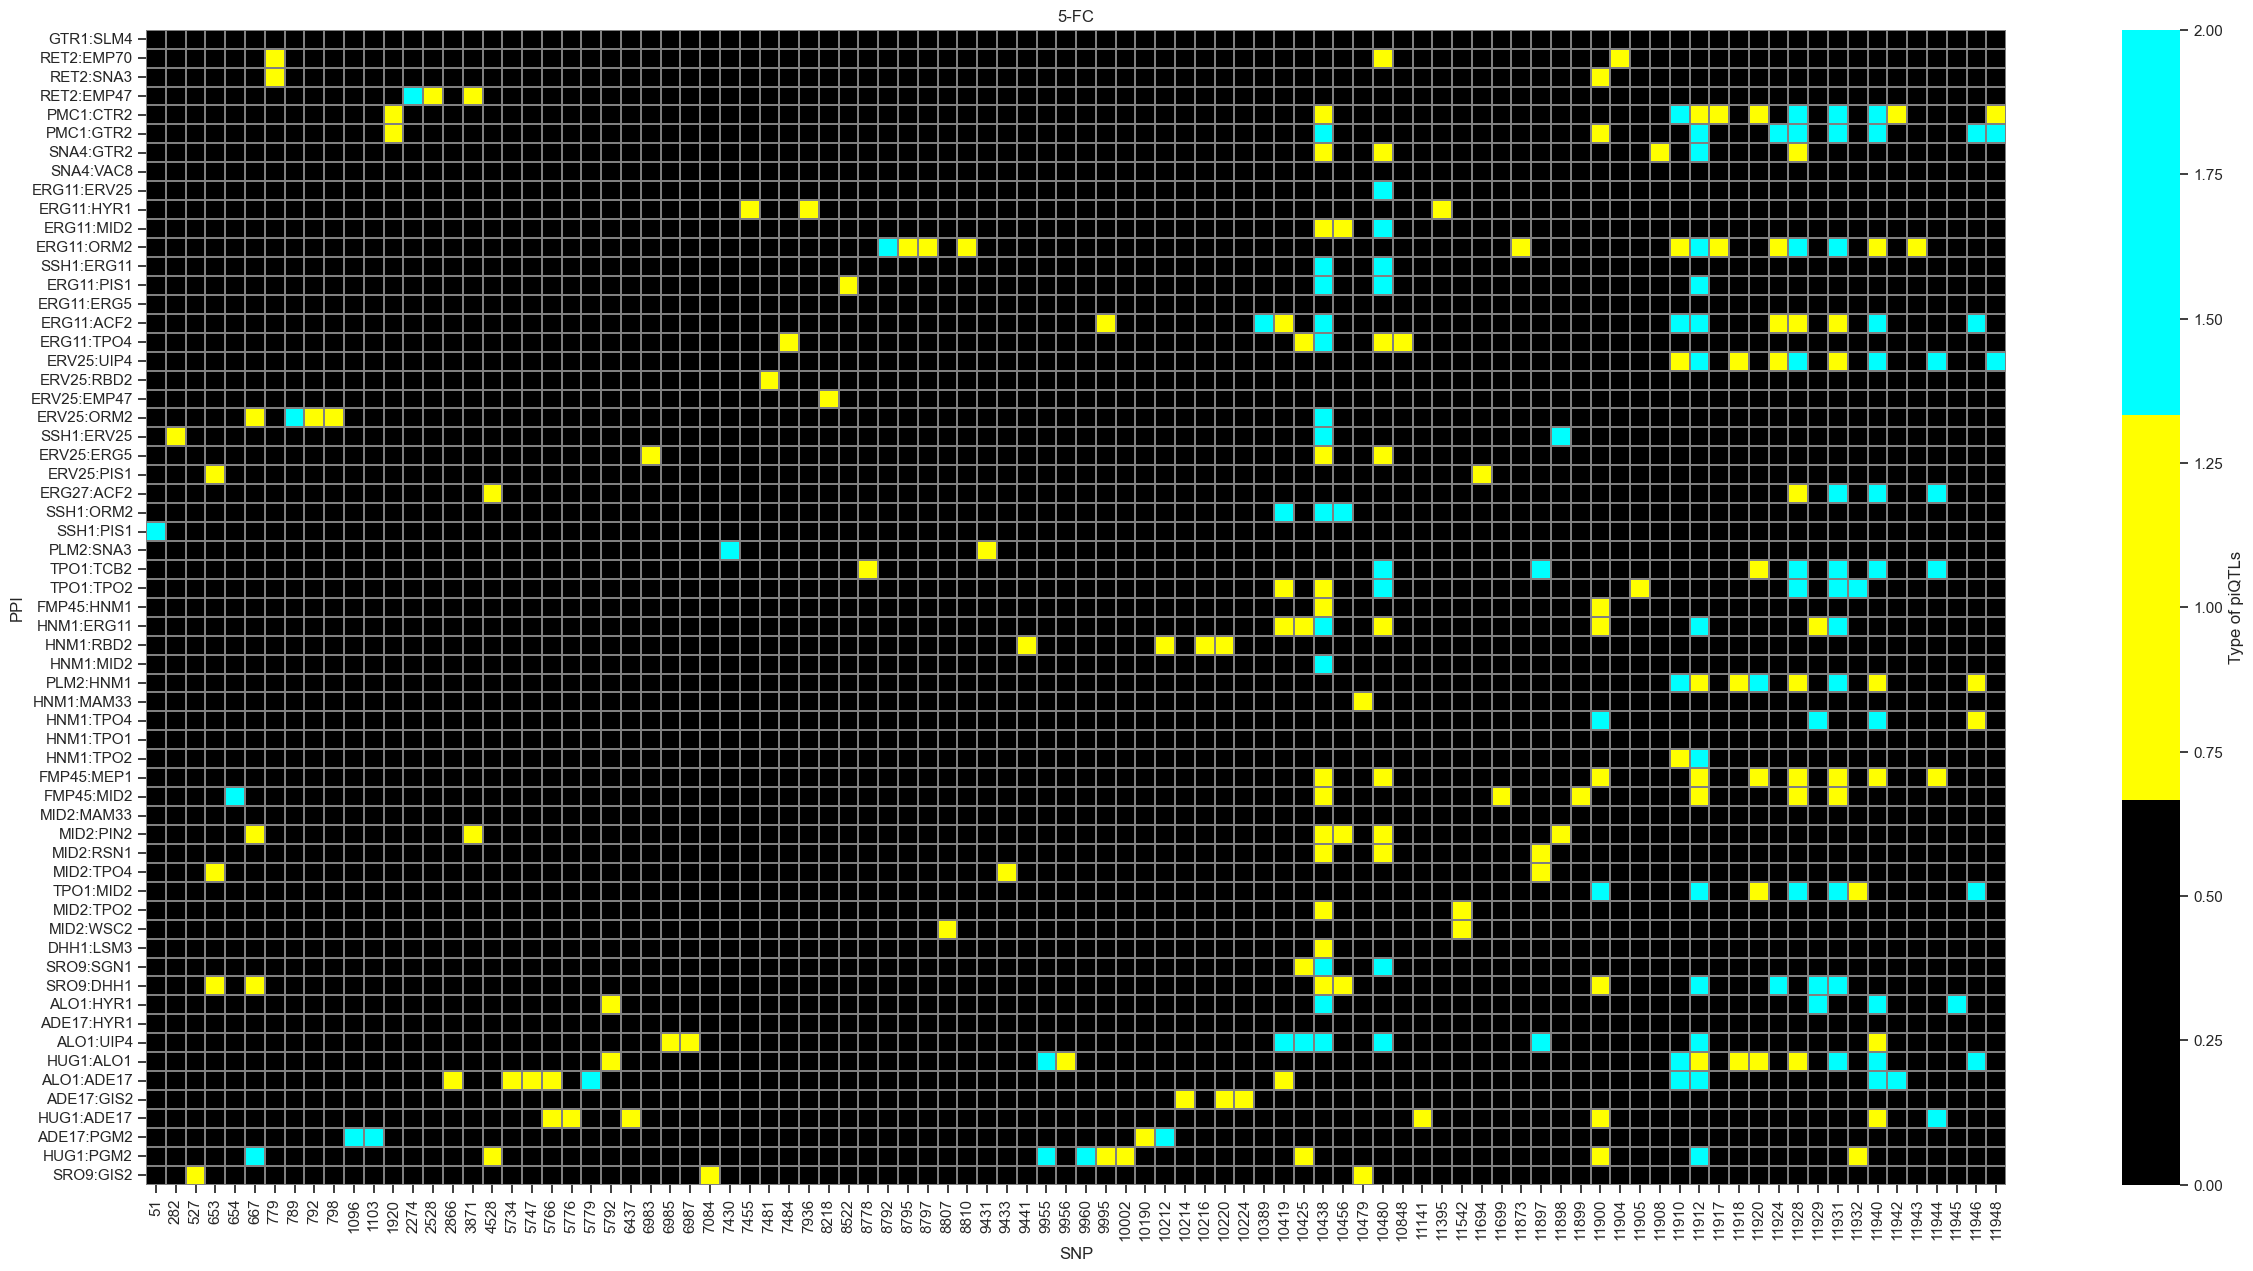

In [111]:
get_heatmap(all_final_piQTLs, '5-FC', 30, 15)

SNP,22,51,277,282,369,370,654,657,658,660,...,11924,11927,11928,11929,11931,11940,11942,11944,11946,11948
PPI,,,,,,,,,,,,,,,,,,,,,
GTR1:SLM4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:EMP70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:SNA3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RET2:EMP47,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PMC1:CTR2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ADE17:GIS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HUG1:ADE17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADE17:PGM2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


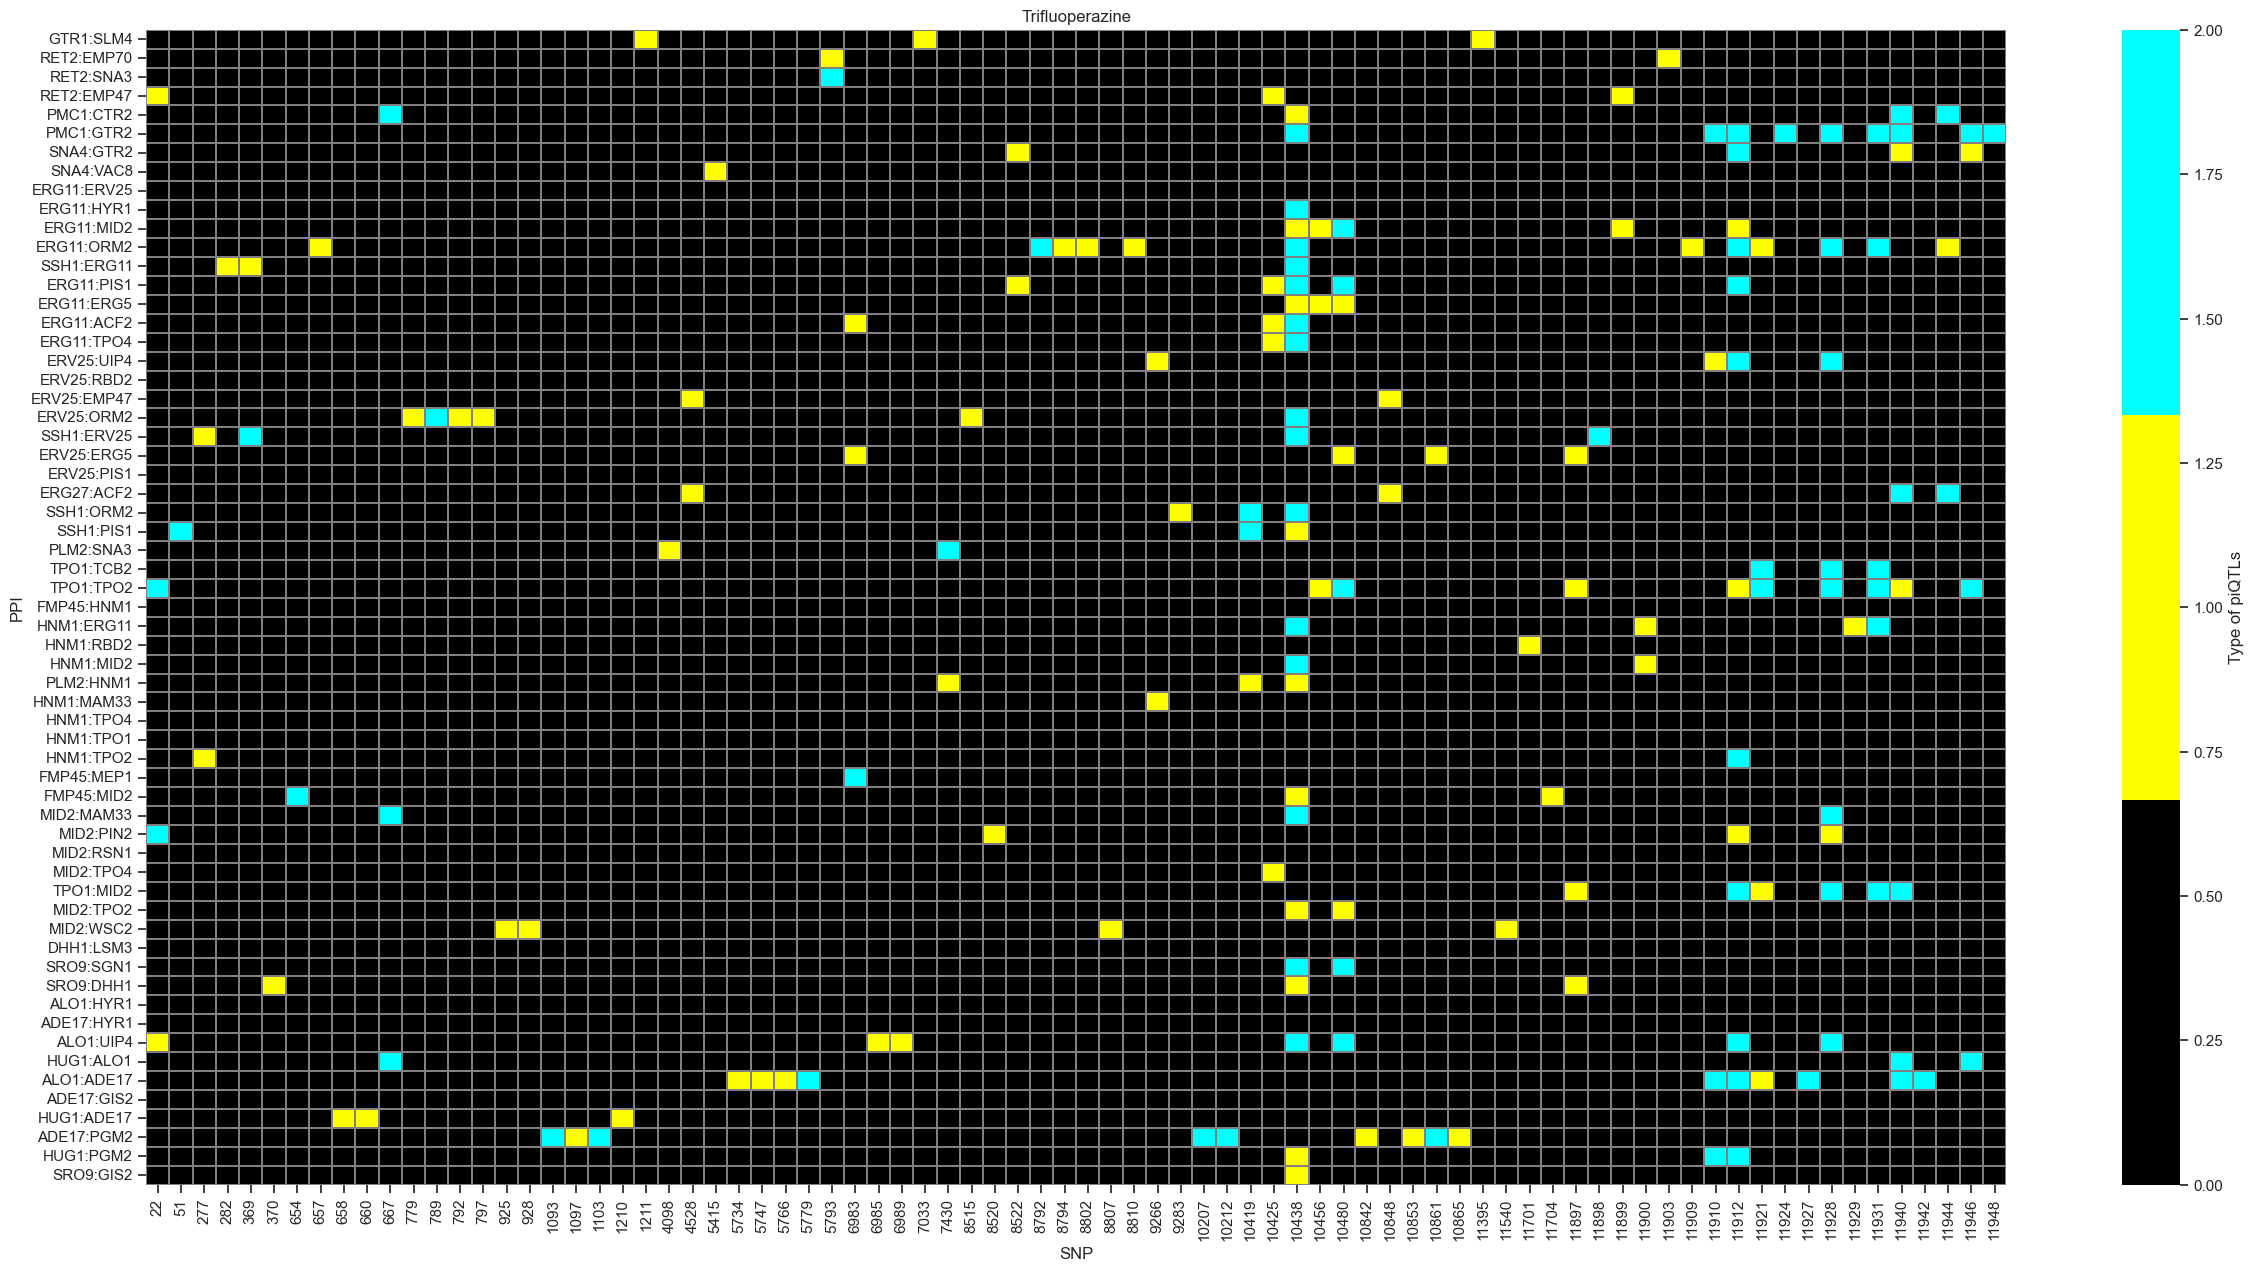

In [112]:
get_heatmap(all_final_piQTLs, 'Trifluoperazine', 30, 15)